
# Enhancing Audio-Visual Cross-Modal Alignment with Contrastive Dual Encoders
**Authors**: Xize He, Yuxuan Tang, Haoran Yang, Zhangqianheng Pan
[School of Computer Science
University of Nottingham
Nottingham, UK]  
[psxxh14@nottingham.ac.uk]

# 1. Introduction and Environment


## Introduction

Cross-modal retrieval, which aligns and retrieves information across disparate modalities such as audio and visual data, is pivotal for applications like multimedia search, environmental sound recognition, and assistive technologies. Humans naturally associate auditory cues, such as "crashing waves," with visual scenes like a beach, yet achieving this alignment computationally remains challenging due to the heterogeneous nature of modality-specific features.

This project introduces a contrastive learning framework to bridge audio and image modalities using a dual-encoder architecture. By leveraging pretrained backbones—OpenL3 for audio and ResNet50 or CLIP for images—we align spectrograms and visual scenes in a shared 128-dimensional embedding space. Our approach employs the InfoNCE loss to optimize semantic alignment, enabling robust retrieval without requiring labeled data. We conduct extensive experiments across 5×5, 10×10, and 20×20 configurations, evaluating the impact of training data scale, encoder architecture (standard vs. PCA-based), and visual encoder choice (ResNet50 vs. CLIP). The following sections detail our methodology, implementation in this Jupyter Notebook, and results, demonstrating the framework’s effectiveness, scalability, and potential for real-world audio-visual applications.

### Environment and Setup

To ensure reproducibility of the experiments in this Jupyter Notebook, we detail the computational environment below:

- **Operating System**: Windows 11
- **Python Version**: 3.10.0
- **Hardware**: CPU (Intel Core i7 or equivalent), optional GPU (NVIDIA RTX 3060 or compatible for CUDA acceleration)
- **Core Libraries**:
  - PyTorch: 2.6.0 (with `torchaudio==2.6.0`, `torchvision==0.21.0`)
  - CLIP: 1.0
  - Librosa: 0.11.0 (with `openl3==0.4.2` for audio feature extraction)
  - Scikit-learn: 1.6.1
  - NumPy: 1.26.0
  - Pandas: 2.2.3
  - Matplotlib: 3.10.1
  - Pillow: 10.4.0
- **Additional Dependencies**:
  - Visualization: Plotly 6.0.1
  - Utilities: TQDM 4.67.1, Requests 2.32.3
  - Jupyter Support: IPyKernel 6.29.5, IPython 8.36.0
- **Installation**:
  All libraries are available via PyPI. Install dependencies using:
  ```bash
  pip install torch==2.6.0 torchaudio==2.6.0 torchvision==0.21.0 clip==1.0 librosa==0.11.0 openl3==0.4.2 scikit-learn==1.6.1 numpy==1.26.0 pandas==2.2.3 matplotlib==3.10.1 pillow==10.4.0 plotly==6.0.1 tqdm==4.67.1 requests==2.32.3 ipykernel==6.29.5 ipython==8.36.0

## Structure of the Submitted Notebook

This Jupyter Notebook implements and analyzes our cross-modal retrieval framework, as described in the accompanying IEEE-format paper, "Enhancing Audio-Visual Cross-Modal Alignment with Contrastive Dual Encoders." The notebook is organized into the following sections to provide a clear and comprehensive exploration of the research:

- **Introduction and Environment**: Introduces the research background, challenges, and objectives of audio-visual cross-modal retrieval, outlining the contrastive learning framework with dual encoders. It also specifies the computational environment, including Python 3.10.0, key libraries (PyTorch, CLIP, Librosa), and hardware for reproducibility (Section 1).
- **Data Processing**: Describes the construction of audio-image pairs from ESC-50 and Places365 datasets, including 5×5, 10×10, and 20×20 configurations with 40 contrastive pairs per audio (Section 2).
- **Feature Extraction**: Explains audio feature extraction using OpenL3 and visual feature extraction with ResNet50 or CLIP, projecting to a 128-dimensional embedding space (Section 3).
- **Contrastive Learning and Testing**: Presents the training process using InfoNCE loss to align audio and visual embeddings, covering standard and PCA-based frameworks. Additionally, outlines the evaluation protocol, using held-out audio samples to compute top-k retrieval accuracy against the Places365 image database (Section 4).
- **Results**: Analyzes experimental outcomes, reporting top-1 retrieval accuracies (e.g., ResNet50: 0.905, CLIP: 0.931, PCA: 0.65 in 5×5 with 40 samples), visualized through accuracy curves, bar charts, and t-SNE scatter plots, with comparisons of data scale and encoder performance (Section 5).

# 2 Data Processing ##

## 2.1 Download ESC-50 and Places-365 Dataset ###

The ESC-50 and Places-365 dataset can be found [here](https://www.kaggle.com/datasets/benjaminkz/places365) and [here](https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50), and you can manually download the datasets and save them in the `data_set_total` directory located in the same directory as this code file. Rename the folders `esc50` and `places365` respectively. This way, you can skip running the dataset download code.

Before installing the dataset, we should install the kagglehub dependency
```bash
pip install kagglehub

In [ ]:
import kagglehub
import os
import shutil

# Create the main directory
target_root = "data_set_total"
os.makedirs(target_root, exist_ok=True)

In [ ]:
# ================== Download ESC-50 Dataset ==================
try:
    print("\nDownloading ESC-50 dataset...")
    # Download to a temporary path
    temp_path = kagglehub.dataset_download("mmoreaux/environmental-sound-classification-50")
    
    # Define the target path
    target_dir = os.path.join(target_root, "esc50")
    
    # Move files to the target path
    shutil.move(temp_path, target_dir)
    print(f"ESC-50 dataset saved to: {target_dir}")

except Exception as e:
    print(f"Download failed: {e}")
    # Clean up residual files (if any)
    if os.path.exists(temp_path):
        shutil.rmtree(temp_path)

 ⚠️ **Warning:** The Places365 dataset is quite large—over 20 GB—and it also needs to be extracted after downloading, which may take around 2 hours to complete.

In [ ]:
# ================== Download Places365 Dataset ==================
try:
    print("Downloading Places365 dataset...")
    # Download to a temporary path
    temp_path = kagglehub.dataset_download("benjaminkz/places365")
    
    # Define the target path
    target_dir = os.path.join(target_root, "places365")
    
    # Move files to the target path
    shutil.move(temp_path, target_dir)
    print(f"Places365 dataset saved to: {target_dir}")

except Exception as e:
    print(f"Download failed: {e}")
    # Clean up residual files (if any)
    if os.path.exists(temp_path):
        shutil.rmtree(temp_path)

## 2.2 Semantic Match construction

### 2.2.1 Audio Category Check

This code extracts unique audio categories from `esc50.csv` (ESC-50), removes duplicates, and saves them to `esc50_unique_categories.csv`. It verifies the `category` column and handles errors, supporting audio-image pair construction for cross-modal retrieval.

In [ ]:
import pandas as pd
import os

# Define paths
base_dir = "data_set_total"
esc50_csv_path = os.path.join(base_dir, "esc50", "esc50.csv")
output_csv_path = os.path.join(base_dir, "esc50_unique_categories.csv")  # Path for the new file

try:
    # Read the original CSV file
    df = pd.read_csv(esc50_csv_path)
    
    # Check if the 'category' column exists
    if 'category' not in df.columns:
        raise KeyError("The CSV file is missing the 'category' column")
    
    # Extract the 'category' column and remove duplicates
    unique_categories = df['category'].drop_duplicates().reset_index(drop=True)
    
    # Save to a new CSV file
    unique_categories.to_csv(output_csv_path, index=False, header=['category'])
    
    # Print results
    print(f"✅ New file generated at: {output_csv_path}")
    print(f"📊 Original category count: {len(df['category'])}")
    print(f"📦 Unique category count after deduplication: {len(unique_categories)}")
    print("\n🔍 First few unique categories:")
    print(unique_categories.head(5).to_string(index=False))

except FileNotFoundError:
    print(f"❌ Error: Original file not found at {esc50_csv_path}")
except KeyError as e:
    print(f"❌ Column error: {str(e)}")
except Exception as e:
    print(f"❌ Processing failed: {str(e)}")


### 2.2.2 Places365 Category Check

This code extracts unique image category labels from the Places365 dataset’s `train` and `val` directories, saving them to `places365_labels.csv`. It scans subdirectories, verifies their existence, and ensures 365 categories are detected, supporting audio-image pair construction for cross-modal retrieval.

In [ ]:
import os
import csv

def extract_places365_labels(dataset_root):
    """
    Extract labels from the directory structure of the Places365 dataset
    Args:
        dataset_root (str): Root directory of the dataset (containing train and val folders)
    Returns:
        list: Sorted list of unique labels
    """
    labels = set()
    folders_to_scan = ["train", "val"]

    for folder in folders_to_scan:
        current_path = os.path.join(dataset_root, folder)
        if not os.path.exists(current_path):
            print(f"⚠️  Warning: Directory not found at {current_path}")
            continue

        for entry in os.listdir(current_path):
            full_path = os.path.join(current_path, entry)
            if os.path.isdir(full_path) and not entry.startswith("."):
                labels.add(entry)

    return sorted(labels)

def save_labels_to_csv(labels, output_path):
    """Save labels to a CSV file"""
    with open(output_path, "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["category"])
        for label in labels:
            writer.writerow([label])

if __name__ == "__main__":
    dataset_root = "./data_set_total/places365"
    output_csv = os.path.join(dataset_root, "..", "places365_labels.csv")

    try:
        labels = extract_places365_labels(dataset_root)

        if len(labels) != 365:
            print(f"⚠️  Warning: Detected {len(labels)} categories, expected 365.")
        else:
            print("✅ Correct number of categories detected (365).")

        save_labels_to_csv(labels, output_csv)
        print(f"\n📄 Label file successfully generated at: {output_csv}")
        print(f"📦 Total categories extracted: {len(labels)}")

        print("\n🔍 First few category names:")
        for label in labels[:5]:
            print(f"   - {label}")

    except Exception as e:
        print(f"❌ Processing failed: {str(e)}")


### 2.2.3 Filtering Manually Rated Audio-Image Pairs

This code processes `100_matches.csv`, derived from a user study where 10 participants rated audio-image pair similarity on a 1-10 scale, to filter high-quality matches for cross-modal retrieval. It converts percentage-based error rates (`image_data_err`, `audio_data_err`) to decimals (e.g., 1% to 0.01) and filters pairs using criteria: grade > 8, `image_data_err` ≤ 0.01, `audio_data_err` < 0.05, and `image_num` ≥ 5000. Filtered audio-place tuples are stored for subsequent pair construction. The table below presents a subset of filtered pairs.

| Audio Category     | Place Category     |
|--------------------|--------------------|
| dog                | dog_park           |
| sea_waves          | beach              |
| chirping_birds     | forest             |
| thunderstorm       | stormy_field       |
| vacuum_cleaner     | living_room        |

**Input**: `100_matches.csv` (user-rated pair metadata).  
**Output**: List of filtered audio-place class pairs.

In [ ]:
import pandas as pd

# Read match CSV
print("📄 Reading the match CSV file: './100_matches.csv'")
df = pd.read_csv('./100_matches.csv')
print("\n📊 First 5 rows of the loaded DataFrame:")
try:
    print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
except ImportError:
    print(df.head().to_string(index=False))

# Convert percentage strings to floats
df['image_data_err'] = df['image_data_err'].str.rstrip('%').astype(float) / 100.0
df['audio_data_err'] = df['audio_data_err'].str.rstrip('%').astype(float) / 100.0

print("\n🧪 Filtering pairs based on conditions: grade > 8, image_data_err <= 0.01, audio_data_err < 0.05, image_num >= 5000...")
high_score_pairs = df[
    (df['grade'] > 8) &
    (df['image_data_err'] <= 0.01) &
    (df['audio_data_err'] < 0.05) &
    (df['image_num'] >= 5000)
][['audio', 'place']].values.tolist()

high_score_pairs = [tuple(pair) for pair in high_score_pairs]
print("\n✅ Successfully read and filtered './100_matches.csv'")
print(f"🔢 Number of pairs after filtering: {len(high_score_pairs)}")
print("\n📋 Sample of filtered pairs (up to 5):")
if high_score_pairs:
    sample_df = pd.DataFrame(high_score_pairs[:5], columns=['Audio Category', 'Place Category'])
    try:
        print(sample_df.to_markdown(index=False, numalign="left", stralign="left"))
    except ImportError:
        print(sample_df.to_string(index=False))
else:
    print("No pairs met the filtering criteria.")

### 2.3 Experiment Configuration for Pair Set Scales

This code defines a global variable `lab_num`, initialized to 0, to denote three experiment configurations (`lab_num = 1, 2, 3`) for cross-modal retrieval, corresponding to 5×5, 10×10, and 20×20 audio-image pair set scales, respectively. These scales reflect increasing dataset complexity, enabling evaluation of model performance across varying category combinations. The variable facilitates switching between setups during preprocessing, feature extraction, and training.

In [ ]:
global lab_num
lab_num = 0

Run before each experiment, it enables switching between scales to evaluate model performance under varying dataset complexity. The code is extensible for additional experiment configurations in the future like 50x50, 100x100 ....

In [ ]:
# Experiment rotation logic (cycles through lab numbers 1-3)
print("Updating lab number...")
lab_num = lab_num % 3 + 1  # Modulo operation ensures lab_num stays between 1-3
LAB_NUM = f'lab{lab_num}'  # Format lab number into string (e.g., 'lab1')

# Experiment configuration mapping
LAB_CONFIGS = {
    1: "5*5",   # Configuration for lab1
    2: "10*10", # Configuration for lab2
    3: "20*20"  # Configuration for lab3
}

# Print current experiment information
print("Current lab:", LAB_NUM)
print("Current data scalability:", LAB_CONFIGS[lab_num])  # Get config from mapping


### 2.3.1 Pair Sampling and Dataset Preparation

This code samples unique audio-image class pairs for cross-modal retrieval experiments (`lab_num = 1, 2, 3`, corresponding to 5×5, 10×10, 20×20 pair set scales) from filtered matches, ensuring no duplicate categories within each lab. It creates experiment-specific directories, copies Places365 image and ESC-50 audio datasets, and saves sampled pairs to `match.json`. The `SAMPLE_SIZES` dictionary (5, 10, 20 pairs) controls scale, with extensibility for additional configurations.

**Input**: Filtered pairs, Places365/ESC-50 datasets.  
**Output**: `match.json`, experiment directories with sampled datasets.

In [ ]:
# Create directories for the current lab
print(f"\n📁 Creating directories for **{LAB_NUM}**...")
os.makedirs(f'{LAB_NUM}/data_set/place-365', exist_ok=True)
print(f"✅ Directory created: `{LAB_NUM}/data_set/place-365`")

# Shuffle the pairs to ensure randomness
print("\n🔀 Shuffling high-score pairs for randomness...")
random.shuffle(high_score_pairs)

# Track used audio and place labels to avoid duplicates within this lab
print("📊 Sampling pairs without duplicate audio/place labels...")
used_audio = set()
used_place = set()
lab_pairs = []

for pair in high_score_pairs:
    audio, place = pair
    if audio not in used_audio and place not in used_place:
        lab_pairs.append(pair)
        used_audio.add(audio)
        used_place.add(place)
    if len(lab_pairs) == SAMPLE_SIZES[lab_num]:
        break

# Check if we have enough unique pairs
if len(lab_pairs) < SAMPLE_SIZES[lab_num]:
    print(f"⚠️  Warning: Not enough unique pairs for `{LAB_NUM}` — requested {SAMPLE_SIZES[lab_num]}, got {len(lab_pairs)}")
else:
    print(f"✅ Successfully sampled {len(lab_pairs)} unique pairs.")

# Display sampled pairs
print(f"\n🔍 Sampled pairs for `{LAB_NUM}`:")
for i, (audio, place) in enumerate(lab_pairs, 1):
    print(f"   {i:02d}. Audio: {audio} → Place: {place}")

# Convert to dictionary format and write to JSON
print(f"\n💾 Writing pairs to `{LAB_NUM}/data_set/match.json`...")
lab_dict = {pair[0]: pair[1] for pair in lab_pairs}
with open(f'{LAB_NUM}/data_set/match.json', 'w', encoding='utf-8') as f:
    json.dump(lab_dict, f, indent=4, ensure_ascii=False)
print(f"✅ `match.json` created with {len(lab_pairs)} pairs.")

# Copy image folders
print("\n🖼️  Copying image folders...")
for _, place in lab_pairs:
    src_folder = os.path.join('data_set_total', 'places365', 'train', place)
    dst_folder = os.path.join(LAB_NUM, 'data_set', 'place-365', place)
    if os.path.exists(src_folder):
        shutil.copytree(src_folder, dst_folder, dirs_exist_ok=True)
        print(f"   ✅ Copied: {place}")
    else:
        print(f"   ⚠️  Missing source folder: {src_folder}")

# Copy the audio dataset
print("\n🎧 Copying ESC-50 audio dataset...")
shutil.copytree('data_set_total/esc50', f'{LAB_NUM}/data_set/esc-50', dirs_exist_ok=True)
print(f"✅ Audio dataset copied to `{LAB_NUM}/data_set/esc-50`")

# Summary of the execution
print("\n" + "=" * 40)
print("📝 **Execution Summary**")
print(f"🧪 Lab number:           {LAB_NUM}")
print(f"📈 Data scale:           {LAB_CONFIGS[lab_num]}")
print(f"🎯 Requested pairs:      {SAMPLE_SIZES[lab_num]}")
print(f"✅ Generated pairs:      {len(lab_pairs)}")
print(f"📂 match.json saved at:  {LAB_NUM}/data_set/match.json")
print(f"🗃️  Audio folder:         {LAB_NUM}/data_set/esc-50")
print(f"🖼️  Image folders:        {LAB_NUM}/data_set/place-365/")
print("=" * 40)


# 3 Feature Extraction 

## 3.1 extract Audio features 

Before extracting the audio feature, we need to generate a file that maps label names to their corresponding numeric indices. Since the model processes labels as numbers, converting them back to names will make the results more readable for humans.

In [ ]:
import pandas as pd
import json
import os

# Load the esc50.csv file
csv_file = f'{LAB_NUM}/data_set/esc-50/esc50.csv'  # Replace with the actual path
df = pd.read_csv(csv_file)

# Create a mapping dictionary for audio tags
audio_class_names = {row['target']: row['category'] for _, row in df.iterrows()}

# Make sure the save path exists
output_dir = f"./{LAB_NUM}/features_openl3"
os.makedirs(output_dir, exist_ok=True)

# Save as class_names.json
class_names_path = os.path.join(output_dir, "class_names.json")
with open(class_names_path, "w") as f:
    json.dump(audio_class_names, f, indent=4)

print(f"Audio class names saved to: {class_names_path}")

The following table illustrates the audio class mapping file derived from the ESC-50 dataset. The complete mapping, containing all 50 classes, is saved as `class_names.json` in the `./features_openl3` directory.

| Label | Category Name   |
|-------------|-----------------|
| 0           | Dog             |
| 1           | Rooster         |
| 2           | Pig             |
| 3           | Cow             |
| 4           | Frog            |

### 3.1.1 Audio Feature Extraction and Storage

This code segment extracts audio features, labels, and filenames from the ESC-50 dataset, saving them as three separate `.npy` files in the `./features_openl3` directory. Using OpenL3, 512-dimensional embeddings are generated for each audio clip, capturing semantic information for cross-modal retrieval. The corresponding class labels and filenames are also extracted, enabling efficient querying by index in subsequent tasks, such as audio-image pair alignment and model training. The output directory is ensured to exist.

**Input**: ESC-50 dataset audio files and metadata (`esc50.csv`).  
**Output**: 
- `audio_features.npy`: 512-D OpenL3 embeddings.
- `audio_labels.npy`: Class indices.
- `audio_filenames.npy`: Audio file paths.

In [104]:
import os
import openl3
import torchaudio
import numpy as np
import pandas as pd

# Set the path
csv_path = f"{LAB_NUM}/data_set/esc-50/esc50.csv"
audio_base_path = f"{LAB_NUM}/data_set/esc-50/audio/audio/44100"
save_dir = f"{LAB_NUM}/features_openl3"
os.makedirs(save_dir, exist_ok=True)

# Read the tag
meta = pd.read_csv(csv_path)

# Initialize feature storage
features = np.zeros((len(meta), 512))  # OpenL3 outputs 512 dimensions by default (can be changed to 6144)
labels_esc = []
filenames = []
valid_count = 0

# Extractor parameters
content_type = "env"  # ESC-50 is environmental sound, not music/speech
embedding_size = 512  # Options: 512 or 6144
input_repr = "mel256"  # OpenL3 default input representation
center = True
hop_size = 1.0  # One vector per second (we'll average them at the end)

print("🚀 Extracting features (OpenL3)...")

# Process files one by one with progress display
total_files = len(meta)
for idx, row in enumerate(meta.itertuples(), 1):  # Using enumerate for indexing
    fname = row.filename
    label = row.target
    fpath = os.path.join(audio_base_path, fname)

    try:
        waveform, sr = torchaudio.load(fpath)
        if sr != 48000:
            waveform = torchaudio.functional.resample(waveform, sr, 48000)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # OpenL3 expects numpy format
        audio_np = waveform.squeeze(0).numpy()

        # Extract features (one segment per hop, needs averaging)
        emb, _ = openl3.get_audio_embedding(audio_np, sr=48000,
                                            input_repr=input_repr,
                                            content_type=content_type,
                                            embedding_size=embedding_size,
                                            center=center,
                                            hop_size=hop_size)

        # Apply mean pooling
        embedding_mean = np.mean(emb, axis=0)
        features[valid_count] = embedding_mean
        labels_esc.append(label)
        filenames.append(fname)
        valid_count += 1

    except Exception as e:
        print(f"❌ Failed to process {fname}: {e}")

    # Print current progress
    print(f"Progress: {idx}/{total_files} ({(idx / total_files) * 100:.2f}%)")

# Trim to valid data only
features = features[:valid_count]
labels_esc = np.array(labels_esc)

# Save results
np.save(os.path.join(save_dir, "esc50_openl3_features.npy"), features)
np.save(os.path.join(save_dir, "esc50_openl3_labels.npy"), labels_esc)

with open(os.path.join(save_dir, "esc50_openl3_filenames.txt"), "w") as f:
    for name in filenames:
        f.write(name + "\n")

print(f"✅ OpenL3 feature extraction completed! Extracted {features.shape[0]} audio segments with dimension {features.shape[1]}")

🚀 Extracting features (OpenL3)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step
Progress: 1/2000 (0.05%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
Progress: 2/2000 (0.10%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
Progress: 3/2000 (0.15%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step

KeyboardInterrupt: 

## 3.2 Extract Features of Images with Resnet50 ###

Before extracting the image feature, we also need to generate a file that maps label names to their corresponding numeric indices for the same reason

In [89]:
import json
import os

# 假设 LAB_NUM 是需要定义的变量，可以根据需要修改
LAB_NUM = "lab1"  # 可以改为您的实验编号

# 从本地读取 match.json 文件
try:
    with open('match.json', 'r', encoding='utf-8') as f:
        match_data = json.load(f)
except FileNotFoundError:
    print("Error: match.json file not found")
    exit(1)

# 获取 match.json 中的所有唯一值并排序
unique_labels = sorted(set(match_data.values()))

# 创建数字与标签的映射
label_map = {}
for i, label in enumerate(unique_labels):
    label_map[str(i)] = label

# 定义输出路径
output_dir1 = f"./{LAB_NUM}/features_image"
output_dir2 = f"./{LAB_NUM}/features_image_clip"

# 如果目录不存在则创建
os.makedirs(output_dir1, exist_ok=True)
os.makedirs(output_dir2, exist_ok=True)

# 将结果写入两个 class_names.json 文件
with open(f"{output_dir1}/class_names.json", 'w', encoding='utf-8') as f:
    json.dump(label_map, f, indent=4)

with open(f"{output_dir2}/class_names.json", 'w', encoding='utf-8') as f:
    json.dump(label_map, f, indent=4)

print(f"class_names.json has been generated successfully in {output_dir1} and {output_dir2}")

Error: match.json file not found
class_names.json has been generated successfully in ./lab1/features_image and ./lab1/features_image_clip


The following table illustrates the audio class mapping file derived from the ESC-50 dataset. The complete mapping, containing all 50 classes, is saved as `class_names.json` in the `./features_image` and `./features_image_clip` directory.

| Label | Category Name   |
|-------------|-----------------|
| 0           | beach           |
| 1           | bedroom         |
| 2           | boardwalk             |
| 3           | doorway-outdoor             |
| 4           | pharmacy            |

### 3.2.1 Image Feature Extraction and Storage

This code segment extracts image features, labels, and file paths from the Places365 dataset, saving them as three `.npy` files and a metadata JSON file in the `./features_image` directory. Using a pretrained ResNet50 model with global average pooling, 2048-dimensional feature embeddings are generated for up to 5,000 images per class, capturing visual semantics for cross-modal retrieval. Class labels and file paths are also stored, enabling efficient indexing for audio-image pair alignment and retrieval tasks. The output directory is created if it does not exist.

**Input**: Places365 dataset images and directory structure.  
**Output**:  
- `image_features.npy`: 2048-D ResNet50 embeddings.  
- `image_labels.npy`: Class labels.  
- `image_paths.npy`: Image file paths.  
- `metadata.json`: Total samples, feature dimension, and class list.

In [90]:
import os
import numpy as np
import json
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tqdm import tqdm

# Output path
FEATURE_DIR = f'./{LAB_NUM}/features_image'
os.makedirs(FEATURE_DIR, exist_ok=True)

# Build ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False)
x = base_model.output
x = GlobalAveragePooling2D()(x)
model = Model(inputs=base_model.input, outputs=x)

# Define data path
DATA_DIR = f'./{LAB_NUM}/data_set/place-365'

# Initialize lists to store all data
all_features = []
all_labels = []
all_paths = []

# Iterate through each class folder
for class_name in os.listdir(DATA_DIR):
    class_dir = os.path.join(DATA_DIR, class_name)

    if not os.path.isdir(class_dir):
        continue

    print(f"Processing class: {class_name}")

    # Process all images in this class
    for img_name in tqdm(os.listdir(class_dir)[:5000]):  # Only process first 5000 images
        img_path = os.path.join(class_dir, img_name)

        if not os.path.isfile(img_path):
            continue

        try:
            # Load and preprocess image
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            # Extract features
            feature = model.predict(img_array, verbose=0)[0]

            # Add to lists
            all_features.append(feature)
            all_labels.append(class_name)
            all_paths.append(f"{class_name}/{img_name}")

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

# Convert to numpy arrays
all_features = np.array(all_features)
all_labels = np.array(all_labels)
all_paths = np.array(all_paths)

# Save as three numpy files (with 'image_' prefix)
np.save(os.path.join(FEATURE_DIR, 'image_features.npy'), all_features)  # Modified
np.save(os.path.join(FEATURE_DIR, 'image_labels.npy'), all_labels)     # Modified
np.save(os.path.join(FEATURE_DIR, 'image_paths.npy'), all_paths)       # Modified

# Save metadata to JSON file
metadata = {
    "total_samples": len(all_features),
    "feature_dim": all_features.shape[1],
    "classes": list(set(all_labels))
}
with open(os.path.join(FEATURE_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Processing completed. Total images processed: {len(all_features)}")
print(f"Features shape: {all_features.shape}")
print(f"Saved to: {FEATURE_DIR}/image_features.npy, image_labels.npy, image_paths.npy")

Processing class: beach


  0%|          | 11/5000 [00:02<17:47,  4.67it/s] 


KeyboardInterrupt: 

## 3.3 Extract Features of Images with Clip ###

### CLIP Image Feature Extraction and Storage

This code segment extracts image features, labels, and file paths from the Places365 dataset using the pretrained CLIP model (ViT-B/32), saving them as three `.npy` files and a metadata JSON file in the `./features_image_clip` directory. The CLIP model generates 512-dimensional feature embeddings for up to 5,000 images per class, capturing rich semantic representations for cross-modal retrieval. Class labels and file paths are stored, enabling efficient indexing for audio-image pair alignment and retrieval tasks. The output directory is created if it does not exist, ensuring robust file handling.

**Input**: Places365 dataset images and directory structure.  
**Output**:  
- `image_features.npy`: 512-D CLIP embeddings.  
- `image_labels.npy`: Class labels.  
- `image_paths.npy`: Image file paths.  
- `metadata.json`: Total samples, feature dimension, and class list.

In [91]:
import os
import numpy as np
import json
import torch
import clip
from PIL import Image
from tqdm import tqdm

# Output path
FEATURE_DIR = f'./{LAB_NUM}/features_image_clip'
os.makedirs(FEATURE_DIR, exist_ok=True)

# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# Define data path
DATA_DIR = f"./{LAB_NUM}/data_set/place-365"

# Initialize lists to store all data
all_features = []
all_labels = []
all_paths = []

# Iterate through each class folder
for class_name in os.listdir(DATA_DIR):
    class_dir = os.path.join(DATA_DIR, class_name)

    if not os.path.isdir(class_dir):
        continue

    print(f"Processing class: {class_name}")

    # Process all images in this class
    for img_name in tqdm(os.listdir(class_dir)[:5000]):  # Only process first 5000 images
        img_path = os.path.join(class_dir, img_name)

        if not os.path.isfile(img_path):
            continue

        try:
            # Load and preprocess image
            img = Image.open(img_path).convert("RGB")
            img_preprocessed = preprocess(img).unsqueeze(0).to(device)  # Shape: (1, 3, 224, 224)

            # Extract features
            with torch.no_grad():
                feature = model.encode_image(img_preprocessed).cpu().numpy()[0]  # Shape: (512,)

            # Add to lists
            all_features.append(feature)
            all_labels.append(class_name)
            all_paths.append(f"{class_name}/{img_name}")

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

# Convert to numpy arrays
all_features = np.array(all_features)
all_labels = np.array(all_labels)
all_paths = np.array(all_paths)

# Save as three numpy files (with 'image_' prefix)
np.save(os.path.join(FEATURE_DIR, 'image_features.npy'), all_features)
np.save(os.path.join(FEATURE_DIR, 'image_labels.npy'), all_labels)
np.save(os.path.join(FEATURE_DIR, 'image_paths.npy'), all_paths)

# Save metadata to JSON file
metadata = {
    "total_samples": len(all_features),
    "feature_dim": all_features.shape[1],
    "classes": list(set(all_labels))
}
with open(os.path.join(FEATURE_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Processing completed. Total images processed: {len(all_features)}")
print(f"Features shape: {all_features.shape}")
print(f"Saved to: {FEATURE_DIR}/image_features.npy, image_labels.npy, image_paths.npy")

Processing class: beach


  1%|          | 32/5000 [00:02<06:35, 12.55it/s]


KeyboardInterrupt: 

# 4: Contrasive Learning and Testing ##

## 4.1 Data loda: Load Image Features(Resnet50) and Audio Features (Openl3) 

### 4.1.1 Audio-Image Feature Loading and Train-Validation Split

This code segment loads audio features (512-D OpenL3 embeddings), labels, and file paths from the ESC-50 dataset, and image features (2048-D ResNet50 embeddings), labels, and file paths from the Places365 dataset, stored in the `./features_openl3` and `./features_image` directories, respectively. It constructs a class label mapping dictionary from `match.json`, linking audio and image categories for cross-modal retrieval. Audio files are grouped by label and split into training (80%) and validation (20%) sets using stratified sampling, stored in variables for efficient indexing. This preprocessing step supports audio-image pair alignment and model training, with CLIP features processed separately.

**Input**:  
- `esc50_openl3_features.npy`, `esc50_openl3_labels.npy`, `esc50_openl3_filenames.txt` (ESC-50).  
- `image_features.npy`, `image_labels.npy`, `image_paths.npy` (Places365, ResNet50).  
- `class_names.json` (audio/image), `match.json` (pair mappings).  

**Output**:  
- Variables: `AUDIO_FEATURES`, `AUDIO_LABELS`, `AUDIO_PATHS`, `IMAGE_FEATURES`, `IMAGE_LABELS`, `IMAGE_PATHS`.  
- Dictionaries: `MATCH_LABEL_DICT` (label-to-label pairing), `TRAIN_AUDIO_FILES`, `VAL_AUDIO_FILES` (train/validation splits).

In [92]:
import json
import os
import numpy as np
from sklearn.model_selection import train_test_split

# Feature paths
IMAGE_DIR = f"./{LAB_NUM}/features_image"
AUDIO_DIR = f"./{LAB_NUM}/features_openl3"
MATCH_FILE = f"./{LAB_NUM}/data_set/match.json"  # Path to match.json

# Load audio and image class_names mapping
with open(os.path.join(AUDIO_DIR, "class_names.json"), "r") as f:
    AUDIO_CLASS_NAMES = json.load(f)

with open(os.path.join(IMAGE_DIR, "class_names.json"), "r") as f:
    IMAGE_CLASS_NAMES = json.load(f)

# Load matched positive sample pairs (match.json)
with open(MATCH_FILE, "r") as f:
    MATCH_DICT = json.load(f)

# Build reverse dictionary for class_name -> label
AUDIO_NAME_TO_LABEL = {v: int(k) for k, v in AUDIO_CLASS_NAMES.items()}
IMAGE_NAME_TO_LABEL = {v: int(k) for k, v in IMAGE_CLASS_NAMES.items()}

# Load audio features and labels
AUDIO_FEATURES = np.load(os.path.join(AUDIO_DIR, "esc50_openl3_features.npy"))
AUDIO_LABELS = np.load(os.path.join(AUDIO_DIR, "esc50_openl3_labels.npy"))
AUDIO_PATHS = np.loadtxt(os.path.join(AUDIO_DIR, "esc50_openl3_filenames.txt"), dtype=str)

# Group by audio_label and extract unique audio_filenames
LABEL_TO_FILES = {}
for label in np.unique(AUDIO_LABELS):
    # Get indices of all files with this label
    indices = np.where(AUDIO_LABELS == label)[0]
    # Extract corresponding unique filenames
    unique_files = np.unique(AUDIO_PATHS[indices])
    LABEL_TO_FILES[label] = unique_files

# Stratified split of unique audio_filenames for each audio_label
TRAIN_AUDIO_FILES = {}
VAL_AUDIO_FILES = {}
for label, filenames in LABEL_TO_FILES.items():
    filenames_list = list(filenames)
    # 80% training set, 20% validation set
    train_fns, val_fns = train_test_split(
        filenames_list,
        test_size=0.2,  # 20% validation set
        random_state=42  # Fixed random seed for reproducibility
    )
    TRAIN_AUDIO_FILES[label] = set(train_fns)
    VAL_AUDIO_FILES[label] = set(val_fns)

# Load image features and labels
IMAGE_FEATURES = np.load(os.path.join(IMAGE_DIR, "image_features.npy"))
IMAGE_NAME_LABELS = np.load(os.path.join(IMAGE_DIR, "image_labels.npy"))
IMAGE_LABELS = np.array([IMAGE_NAME_TO_LABEL[label] for label in IMAGE_NAME_LABELS])

IMAGE_PATHS = np.load(os.path.join(IMAGE_DIR, "image_paths.npy"))

# Generate label number pairing dictionary (label -> label)
MATCH_LABEL_DICT = {}
for audio_name, image_name in MATCH_DICT.items():
    if audio_name in AUDIO_NAME_TO_LABEL and image_name in IMAGE_NAME_TO_LABEL:
        audio_label = AUDIO_NAME_TO_LABEL[audio_name]
        image_label = IMAGE_NAME_TO_LABEL[image_name]
        MATCH_LABEL_DICT[audio_label] = image_label
    else:
        print(f"⚠️ Failed to find matching labels: {audio_name} -> {image_name}")
# print(MATCH_LABEL_DICT)

print("✅ Label number pairing MATCH_LABEL_DICT:")
for k, v in MATCH_LABEL_DICT.items():
    print(f"Audio label {k} ({AUDIO_CLASS_NAMES[str(k)]}) -> Image label {v} ({IMAGE_CLASS_NAMES[str(v)]})")

FileNotFoundError: [Errno 2] No such file or directory: './lab1/features_openl3\\esc50_openl3_features.npy'

## 4.2 Construct Positive and Negative Sample Pairs(Resnet50 + openl3)

This code segment constructs positive and negative sample pairs for contrastive learning, using audio features (512-D OpenL3) from ESC-50 and image features (2048-D ResNet50) from Places365, loaded from `./features_openl3` and `./features_image`. For each audio sample, 40 positive pairs (matching audio-image classes) and 40 negative pairs (non-matching classes) are generated based on `match.json`, with `samples_per_audio` adjustable (e.g., 5, 40, 100, 200) to experiment with varying sample sizes. Pairs, labels, and metadata are saved as `.npy` files and a JSON file in `./contrastive_pairs`.

**Input**:  
- `esc50_openl3_features.npy`, `esc50_openl3_labels.npy`, `esc50_openl3_filenames.txt` (ESC-50).  
- `image_features.npy`, `image_labels.npy`, `image_paths.npy` (Places365, ResNet50).  
- `match.json` (audio-image class mappings).  

**Output**:  
- `audio_pairs.npy`: Audio feature embeddings.  
- `image_pairs.npy`: Image feature embeddings.  
- `pair_labels.npy`: Pair labels (1 for positive, 0 for negative).  
- `pair_metadata.json`: Pair metadata (audio/image indices, labels, filenames, pair type).

In [ ]:
# Increase number of sample pairs
samples_per_audio = 40 # adjustable (e.g., 5, 40, 100, 200)
print("current samoles number per audio : ", samples_per_audio)

In [ ]:
import os
import numpy as np
import random
import json

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Construct positive and negative sample pairs
positive_pairs = []
negative_pairs = []
all_pairs = []
pair_labels = []
pair_metadata = []  # For storing pair metadata


print("📌 Constructing sample pairs:")

# Load audio filenames
audio_filenames = np.loadtxt(os.path.join(AUDIO_DIR, "esc50_openl3_filenames.txt"), dtype=str)

total_audio_samples = sum(
    len(np.where(AUDIO_LABELS == AUDIO_NAME_TO_LABEL[audio_label_name])[0])
    for audio_label_name in MATCH_DICT if audio_label_name in AUDIO_NAME_TO_LABEL
)

processed_audio_samples = 0

for audio_label_name, image_label_name in MATCH_DICT.items():
    if audio_label_name not in AUDIO_NAME_TO_LABEL or image_label_name not in IMAGE_NAME_TO_LABEL:
        print(f"❌ Invalid match: {audio_label_name} -> {image_label_name}")
        continue

    audio_label = AUDIO_NAME_TO_LABEL[audio_label_name]
    image_label = IMAGE_NAME_TO_LABEL[image_label_name]

    if image_label not in IMAGE_LABELS:
        print(f"⚠️ Missing features for image class {image_label}, skipping this match")
        continue

    # Find all audio sample indices for this audio class
    audio_indices = np.where(AUDIO_LABELS == audio_label)[0]
    if len(audio_indices) == 0:
        print(f"⚠️ No samples found for audio class {audio_label_name}")
        continue

    for audio_idx in audio_indices:
        # === Progress display ===
        processed_audio_samples += 1
        progress = processed_audio_samples / total_audio_samples * 100
        print(f"\r🚧 Generating samples... {processed_audio_samples}/{total_audio_samples} "
              f"({progress:.2f}%)", end='')

        audio_feat = AUDIO_FEATURES[audio_idx]
        audio_filename = audio_filenames[audio_idx]

        # Positive sample pairs
        # 1. Find all indices matching target_label
        matching_indices = np.where(IMAGE_LABELS == image_label)[0]

        # 2. Randomly select samples_per_audio indices (without replacement)
        selected_indices = np.random.choice(matching_indices, size=samples_per_audio, replace=False)

        # 3. Extract selected features and paths
        for idx in selected_indices:
            image_feat = IMAGE_FEATURES[idx]  # Extract single feature (shape: (2048,))
            image_filename = IMAGE_PATHS[idx]       # Extract single path (string)

            positive_pairs.append((audio_feat, image_feat))
            all_pairs.append((audio_feat, image_feat))
            pair_labels.append(1)

            # Record metadata
            pair_metadata.append({
                "audio_index": int(audio_idx),
                "audio_label": int(audio_label),
                "audio_class_name": audio_label_name,
                "audio_filename": audio_filename,
                "image_label": int(image_label),
                "image_class_name": image_label_name,
                "image_filename": image_filename,
                "pair_type": "positive"
            })

        # Negative sample pairs
        neg_indices = np.where(IMAGE_LABELS != image_label)[0]  # All non-matching indices

        # Random selection (without replacement)
        neg_selected_indices = np.random.choice(neg_indices, size=samples_per_audio, replace=False)

        for idx in neg_selected_indices:
            neg_image_feat = IMAGE_FEATURES[idx]  # Extract single feature (shape: (2048,))
            neg_image_filename = IMAGE_PATHS[idx]       # Extract single path (string)
            neg_label = IMAGE_LABELS[idx]
            negative_pairs.append((audio_feat, neg_image_feat))
            all_pairs.append((audio_feat, neg_image_feat))
            pair_labels.append(0)
            # Record metadata
            pair_metadata.append({
                "audio_index": int(audio_idx),
                "audio_label": int(audio_label),
                "audio_class_name": audio_label_name,
                "audio_filename": audio_filename,
                "image_label": int(neg_label),
                "image_class_name": IMAGE_CLASS_NAMES[str(neg_label)],
                "image_filename": neg_image_filename,
                "pair_type": "negative"
            })

# Combine positive and negative samples
all_labels = np.array(pair_labels)

# Split into two arrays: audio, image
audio_pair_features = np.array([pair[0] for pair in all_pairs])
image_pair_features = np.array([pair[1] for pair in all_pairs])

# Create output directory for sample pairs (if not exists)
pair_output_dir = f"./{LAB_NUM}/contrastive_pairs"
os.makedirs(pair_output_dir, exist_ok=True)

# Save sample pairs
np.save(os.path.join(pair_output_dir, "audio_pairs.npy"), audio_pair_features)
np.save(os.path.join(pair_output_dir, "image_pairs.npy"), image_pair_features)
np.save(os.path.join(pair_output_dir, "pair_labels.npy"), all_labels)

# Save metadata
with open(os.path.join(pair_output_dir, "pair_metadata.json"), "w") as f:
    json.dump(pair_metadata, f, indent=2)

# Print total number of sample pairs
print("\nGenerated sample pairs count:")
print(f"Positive pairs: {len(positive_pairs)}")
print(f"Negative pairs: {len(negative_pairs)}")
print(f"Total pairs: {len(all_pairs)}")

## 4.3 Training and Testing the Standard Framework

This segment trains a dual-encoder model using the standard framework, aligning 512-D OpenL3 audio features (ESC-50) and 2048-D ResNet50 image features (Places365) into a 128-dimensional shared embedding space via InfoNCE loss. It loads positive and negative sample pairs from `./contrastive_pairs`, splits them into 80/20 training/validation sets, and optimizes audio and image encoders with AdamW, cosine annealing, and mixed-precision training over 50 epochs. Variable names (e.g., `AUDIO_FEATURES`, `TRAIN_LOADER`) are capitalized for enhanced readability. Best and latest models are saved to `./models_Proj` based on validation loss, supporting cross-modal retrieval evaluation

In [94]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import os
import json
from collections import defaultdict
import time

### 4.3.1 dual-encoder defination

Below are two neural network modules designed for feature encoding, processing audio and image inputs respectively, and mapping high-dimensional features into a lower-dimensional embedding space.

#### AudioEncoder_PROJ
`AudioEncoder_PROJ` is an audio feature encoder that transforms audio input features into an embedding vector of a specified dimension.

- **Input Dimension**: 512 (default)
- **Output Embedding Dimension**: 128 (default)
- **Network Architecture**:
  1. Linear Layer: 512 → 512
  2. Batch Normalization (BatchNorm1d): 512
  3. ReLU Activation
  4. Dropout: 0.3 dropout rate
  5. Linear Layer: 512 → 256
  6. ReLU Activation
  7. Linear Layer: 256 → 128 (embedding dimension)
- **Purpose**: Gradually reduces dimensionality and applies nonlinear transformations to map audio features into a 128-dimensional embedding space.

#### ImageEncoder_PROJ
`ImageEncoder_PROJ` is an image feature encoder that converts image input features into an embedding vector of a specified dimension.

- **Input Dimension**: 2048 (default)
- **Output Embedding Dimension**: 128 (default)
- **Network Architecture**:
  1. Linear Layer: 2048 → 1024
  2. Batch Normalization (BatchNorm1d): 1024
  3. ReLU Activation
  4. Dropout: 0.3 dropout rate
  5. Linear Layer: 1024 → 512
  6. ReLU Activation
  7. Linear Layer: 512 → 128 (embedding dimension)
- **Purpose**: Uses multiple layers of dimensionality reduction and regularization to map image features into a 128-dimensional embedding space, aligning with audio embeddings.

In [95]:
# ======================
# Enhanced Encoder Networks
# ======================
class AudioEncoder_PROJ(nn.Module):
    def __init__(self, input_dim=512, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        return self.net(x)

class ImageEncoder_PROJ(nn.Module):
    def __init__(self, input_dim=2048, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        return self.net(x)


### 4.3.2 InfoNCE Loss Defination
InfoNCELoss_PROJ is an enhanced InfoNCE loss designed for aligning audio and image embeddings in contrastive learning.
- Purpose: Encourages positive audio-image pairs to be similar while separating negative pairs.
- Key Parameter: temperature (default: 0.1).
- Process: Normalizes embeddings, computes similarity, and applies symmetric cross-entropy loss.
- Application: Used to compare the similarity between audio and image embeddings for tasks like cross-modal retrieval.
#### Formula
The loss is defined as:
$$ L = \frac{1}{2} \left( L_{a \to v} + L_{v \to a} \right) $$
Where:
Audio-to-image loss:
$$ L_{a \to v} = -\frac{1}{N} \sum_{i=1}^N \log \frac{\exp(a_i \cdot v_i / \tau)}{\sum_{j=1}^N \exp(a_i \cdot v_j / \tau)} $$
Image-to-audio loss:
$$ L_{v \to a} = -\frac{1}{N} \sum_{i=1}^N \log \frac{\exp(v_i \cdot a_i / \tau)}{\sum_{j=1}^N \exp(v_i \cdot a_j / \tau)} $$
( a_i, v_i ): Normalized audio and image embeddings
( \tau ): Temperature parameter
( N ): Batch size

In [ ]:
# ======================
# Improved InfoNCE Loss
# ======================
class InfoNCELoss_PROJ(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, audio_emb, image_emb):
        # Normalize embeddings
        audio_emb = F.normalize(audio_emb, dim=1)
        image_emb = F.normalize(image_emb, dim=1)

        # Compute similarity matrix
        logits = torch.matmul(audio_emb, image_emb.T) / self.temperature
        labels = torch.arange(len(audio_emb)).to(audio_emb.device)

        # Symmetric loss
        loss = (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2
        return loss

### 4.3.3 Training  the Standard Framework
Trains a model to align audio and image embeddings using contrastive learning, evaluates performance with a loss function, and saves the optimized model.

In [102]:

# ======================
# Dataset Definition
# ======================
class ContrastiveDataset_PROJ(Dataset):
    def __init__(self, audio_feats, image_feats, labels):
        self.audio_feats = audio_feats
        self.image_feats = image_feats
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.audio_feats[idx], dtype=torch.float32),
            torch.tensor(self.image_feats[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# ======================
# Validation
# ======================
def evaluate_PROJ(audio_encoder, image_encoder, val_loader, criterion, device):
    audio_encoder.eval()
    image_encoder.eval()
    total_loss = 0.0

    with torch.no_grad():
        for audio_batch, image_batch, _ in val_loader:
            audio_batch = audio_batch.to(device)
            image_batch = image_batch.to(device)

            with autocast():
                audio_embed = audio_encoder(audio_batch)
                image_embed = image_encoder(image_batch)
                loss = criterion(audio_embed, image_embed)

            total_loss += loss.item()

    return total_loss / len(val_loader)

# ======================
# Optimized Training
# ======================
def train_PROJ(epochs=50, batch_size=256, lr=1e-4):
    # Load raw features
    audio_feats = np.load(f"./{LAB_NUM}/contrastive_pairs/audio_pairs.npy")  # Shape: [N, 512]
    image_feats = np.load(f"./{LAB_NUM}/contrastive_pairs/image_pairs.npy")  # Shape: [N, 2048]
    labels = np.load(f"./{LAB_NUM}/contrastive_pairs/pair_labels.npy")
    # Load JSON file
    json_path = f"./{LAB_NUM}/contrastive_pairs/pair_metadata.json"
    with open(json_path, 'r') as f:
        pair_metadata = json.load(f)

    # Standardize features
    audio_scaler = StandardScaler()
    image_scaler = StandardScaler()
    audio_feats = audio_scaler.fit_transform(audio_feats)
    image_feats = image_scaler.fit_transform(image_feats)

    # Record training and validation indices
    train_indices = []
    val_indices = []

    for idx, pair in enumerate(pair_metadata):
        label = pair["audio_label"]
        filename = pair["audio_filename"]
        if filename in TRAIN_AUDIO_FILES[label]:
            train_indices.append(idx)
        elif filename in VAL_AUDIO_FILES[label]:
            val_indices.append(idx)

    # Split into training and validation sets based on indices
    train_audio = audio_feats[train_indices]
    train_image = image_feats[train_indices]
    train_labels = labels[train_indices]

    val_audio = audio_feats[val_indices]
    val_image = image_feats[val_indices]
    val_labels = labels[val_indices]

    # Create datasets
    train_dataset = ContrastiveDataset_PROJ(train_audio, train_image, train_labels)
    val_dataset = ContrastiveDataset_PROJ(val_audio, val_image, val_labels)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # Initialize models
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    audio_encoder = AudioEncoder_PROJ().to(device)
    image_encoder = ImageEncoder_PROJ().to(device)
    criterion = InfoNCELoss_PROJ(temperature=0.1)

    # Optimizer with weight decay
    optimizer = optim.AdamW(
        list(audio_encoder.parameters()) + list(image_encoder.parameters()),
        lr=lr,
        weight_decay=1e-5
    )

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Mixed precision training
    scaler = GradScaler()

    best_val_loss = float('inf')
    model_dir = f"./{LAB_NUM}/models_Proj"
    os.makedirs(model_dir, exist_ok=True)

    for epoch in range(epochs):
        epoch_start = time.time()  # Start timer for the epoch
        audio_encoder.train()
        image_encoder.train()
        epoch_loss = 0.0

        for audio_batch, image_batch, _ in train_loader:
            audio_batch = audio_batch.to(device, non_blocking=True)
            image_batch = image_batch.to(device, non_blocking=True)

            optimizer.zero_grad()

            with autocast():
                audio_emb = audio_encoder(audio_batch)
                image_emb = image_encoder(image_batch)
                loss = criterion(audio_emb, image_emb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

        scheduler.step()
        avg_train_loss = epoch_loss / len(train_loader)

        # Validation
        val_loss = evaluate_PROJ(audio_encoder, image_encoder, val_loader, criterion, device)
        epoch_time = time.time() - epoch_start  # Calculate epoch duration

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.2e}, Time: {epoch_time:.2f}s")

        # Save best and latest models
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "audio_encoder": audio_encoder.state_dict(),
                "image_encoder": image_encoder.state_dict(),
                "optimizer": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_loss": best_val_loss
            }, os.path.join(model_dir, "best_contrastive_model.pth"))
            print(f"✅ Best model saved (Val Loss: {val_loss:.4f})")

        torch.save({
            "audio_encoder": audio_encoder.state_dict(),
            "image_encoder": image_encoder.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss
        }, os.path.join(model_dir, "latest_contrastive_model.pth"))

if __name__ == "__main__":
    train_PROJ(epochs=50, batch_size=256, lr=1e-4)

FileNotFoundError: [Errno 2] No such file or directory: './lab1/contrastive_pairs/audio_pairs.npy'

### 4.3.4 Testing the Standard Framework

#### Cross-Modal Retrieval Testing with Standard Framework

This segment evaluates the cross-modal retrieval performance of the trained standard framework dual-encoder model, using 512-D OpenL3 audio features (ESC-50) and 2048-D ResNet50 image features (Places365). It loads the best model checkpoint from `./models_Proj`, generates 128-D embeddings, and computes top-1 retrieval accuracy by querying validation audio samples against the Places365 image database using cosine similarity. Per-class and overall accuracies are logged to `retrieval_log.txt` and `class_accuracies.txt` in the project directory, supporting performance analysis. It is recommended to manually save the test results after each test for subsequent analysis

**Input**:  
- `best_contrastive_model.pth` (trained model checkpoint).  
- `esc50_openl3_features.npy`, `esc50_openl3_labels.npy`, `esc50_openl3_filenames.txt` (ESC-50).  
- `image_features.npy`, `image_labels.npy`, `image_paths.npy` (Places365, ResNet50).  
- `match.json` (audio-image class mappings).  

**Output**:  
- `retrieval_log.txt`: Detailed retrieval results (audio/image indices, labels, similarities, matches).  
- `class_accuracies.txt`: Per-class top-1 retrieval accuracies.  
- Console output: Overall top-1 retrieval accuracy.

In [ ]:
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler


def evaluate_retrieval_per_class_PROJ(audio_embeddings, image_embeddings, top_k=1, log_file=f"{LAB_NUM}/retrieval_log.txt"):
    """
    Evaluate retrieval accuracy per class
    Parameters:
    - audio_embeddings: audio embedding vectors
    - image_embeddings: image embedding vectors
    - top_k: return top k most similar results
    - log_file: path to log file
    """
    total = 0
    correct = 0
    class_accuracies = {}
    log_data = []

    for audio_label_name, image_label_name in MATCH_DICT.items():
        if audio_label_name not in AUDIO_NAME_TO_LABEL or image_label_name not in IMAGE_NAME_TO_LABEL:
            print(f"❌ Invalid match: {audio_label_name} -> {image_label_name}")
            continue

        audio_label = AUDIO_NAME_TO_LABEL[audio_label_name]
        image_label = IMAGE_NAME_TO_LABEL[image_label_name]

        audio_indices = np.where(AUDIO_LABELS == audio_label)[0]
        if len(audio_indices) == 0:
            print(f"⚠️ No samples found for audio class {audio_label_name}")
            continue

        val_filenames = VAL_AUDIO_FILES[audio_label]  # Validation set filenames for current audio_label

        selected_audio_indices = np.where(np.isin(AUDIO_PATHS, list(val_filenames)))[0]
        if len(selected_audio_indices) == 0:
            print(f"⚠️ No samples found for audio class {audio_label_name}")
            continue

        correct_for_class = 0
        total_for_class = 0

        for audio_idx in selected_audio_indices:
            label = AUDIO_LABELS[audio_idx]
            query_embed = audio_embeddings[audio_idx].unsqueeze(0)  # [1, 128]
            sims = torch.nn.functional.cosine_similarity(query_embed, image_embeddings, dim=1).cpu().numpy()
            top_k_indices = np.argsort(sims)[-top_k:][::-1]
            top_k_labels = IMAGE_LABELS[top_k_indices]

            if image_label in top_k_labels:
                match = True
            else:
                match = False

            log_data.append({
                "audio_idx": audio_idx,
                "audio_label": label,
                "top_k_labels": top_k_labels.tolist(),
                "similarities": sims[top_k_indices].tolist(),
                "match": match,
                "audio_filename": AUDIO_PATHS[audio_idx],
                "image_filenames": [IMAGE_PATHS[i] for i in top_k_indices]
            })

            if match:
                correct_for_class += 1
            total_for_class += 1

        class_accuracy = correct_for_class / total_for_class if total_for_class > 0 else 0
        class_accuracies[label] = class_accuracy

        correct += correct_for_class
        total += total_for_class

        print(f"Class {label}: Top-{top_k} retrieval accuracy: {class_accuracy:.4f}")

    accuracy = correct / total if total > 0 else 0
    print(f"\n🎯 Top-{top_k} retrieval accuracy (per class sampling): {accuracy:.4f}")

    with open(log_file, "w") as f:
        for entry in log_data:
            f.write(
                f"Audio index: {entry['audio_idx']}, "
                f"Audio label: {entry['audio_label']}, "
                f"Audio filename: {entry['audio_filename']}, "
                f"Top-K labels: {entry['top_k_labels']}, "
                f"Image filenames: {entry['image_filenames']}, "
                f"Similarities: {entry['similarities']}, "
                f"Match: {entry['match']}\n"
            )

    return accuracy, class_accuracies

def main():
    # Set model path, consistent with training script
    model_path = f"./{LAB_NUM}/models_Proj/best_contrastive_model.pth"

    # Load and standardize features, consistent with training script
    audio_scaler = StandardScaler()
    image_scaler = StandardScaler()
    audio_features_scaled = audio_scaler.fit_transform(AUDIO_FEATURES)  # Shape: [N, 512]
    image_features_scaled = image_scaler.fit_transform(IMAGE_FEATURES)  # Shape: [N, 2048]

    # Initialize model, consistent with architecture in training script
    audio_encoder = AudioEncoder_PROJ(input_dim=512, embedding_dim=128)
    image_encoder = ImageEncoder_PROJ(input_dim=2048, embedding_dim=128)

    # Load trained model weights
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(model_path, map_location=device)
    audio_encoder.load_state_dict(checkpoint["audio_encoder"])
    image_encoder.load_state_dict(checkpoint["image_encoder"])
    audio_encoder.to(device).eval()
    image_encoder.to(device).eval()

    # Extract embeddings
    with torch.no_grad():
        audio_embeddings = audio_encoder(torch.tensor(audio_features_scaled, dtype=torch.float32).to(device))  # [N, 128]
        image_embeddings = image_encoder(torch.tensor(image_features_scaled, dtype=torch.float32).to(device))  # [N, 128]

    # Evaluate retrieval performance
    overall_accuracy, class_accuracies = evaluate_retrieval_per_class_PROJ(
        audio_embeddings=audio_embeddings,
        image_embeddings=image_embeddings,
        top_k=1,
        log_file=f"{LAB_NUM}/retrieval_log.txt" 
    )

    # Save per-class accuracies
    with open(f"./{LAB_NUM}/class_accuracies.txt", "w") as f:
        for label, accuracy in class_accuracies.items():
            f.write(f"Class {label}: {accuracy:.4f}\n")

    print(f"\nOverall Top-1 retrieval accuracy: {overall_accuracy:.4f}")


if __name__ == "__main__":
    main()

## 4.4 Training and Testing the PCA-based lightweight framework

#### Contrastive Learning Training with PCA-based Lightweight Framework

This segment trains a small dual-encoder model using the lightweight PCA-based framework, aligning PCA-reduced 128-dimensional audio (OpenL3, ESC-50) and image (ResNet50, Places365) features into a shared embedding space via contrastive loss with a margin of 1.0. It loads positive and negative sample pairs from `./contrastive_pairs`, splits them into 80/20 training/validation sets, and optimizes single-layer MLPs using Adam over 20 epochs. Variable names (e.g., `AUDIO_FEATURES`, `TRAIN_LOADER`) are capitalized for enhanced readability. Best and latest models are saved to `./models_PCA` based on validation loss, enabling comparison with the standard framework for cross-modal retrieval evaluation.

**Input**:  
- `audio_pairs.npy`, `image_pairs.npy`, `pair_labels.npy`, `pair_metadata.json` (contrastive pairs).  

**Output**:  
- `best_contrastive_model.pth`: Best model checkpoint (lowest validation loss).  
- `contrastive_model.pth`: Latest model checkpoint.  

In [99]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import json

### 4.4.1 Lightweight Encoder defination

- **`AudioEncoder`**: Transforms audio features into embeddings for alignment.
- **`ImageEncoder`**: Converts image features into embeddings for alignment.

**Function**: Maps audio and image inputs to a shared embedding space using lightweight neural networks.

In [101]:
# ======================
# Encoder Networks
# ======================
class AudioEncoder(nn.Module):
    def __init__(self, input_dim = 128, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class ImageEncoder(nn.Module):
    def __init__(self, input_dim = 128, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, embedding_dim),  # Input dimension should be 128
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

### 4.4.2 Contrastive Loss Defination

`ContrastiveLoss` measures the distance between embedding pairs to encourage similar pairs to be close and dissimilar pairs to be apart.

- **Purpose**: Optimizes embedding alignment based on pair similarity.
- **Key Parameter**: `margin` (default: 1.0).

#### Formula

$$ L = \frac{1}{2} \left[ y \cdot ||o_1 - o_2||_2^2 + (1 - y) \cdot \max(0, m - ||o_1 - o_2||_2)^2 \right] $$

Where:
- \( o_1, o_2 \): Embedding outputs
- \( y \): Label (1 for similar, 0 for dissimilar)
- \( m \): Margin
- \( ||\cdot||_2 \): Euclidean norm

In [ ]:

# ======================
# Contrastive Loss
# ======================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Euclidean distance
        dist = torch.norm(output1 - output2, p=2, dim=1)
        loss = 0.5 * (label * dist.pow(2) + (1 - label) * torch.clamp(self.margin - dist, min=0).pow(2))
        return loss.mean()

In [ ]:

# ======================
# Dataset Definition
# ======================
class ContrastiveDataset(Dataset):
    def __init__(self, audio_feats, image_feats, labels):
        self.audio_feats = audio_feats
        self.image_feats = image_feats
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.audio_feats[idx], dtype=torch.float32),
            torch.tensor(self.image_feats[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# ======================
# Validation
# ======================
def evaluate(audio_encoder, image_encoder, val_loader, criterion, device):
    audio_encoder.eval()
    image_encoder.eval()
    total_loss = 0.0
    with torch.no_grad():
        for audio_batch, image_batch, label_batch in val_loader:
            audio_batch = audio_batch.to(device)
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)

            # Forward
            audio_embed = audio_encoder(audio_batch)
            image_embed = image_encoder(image_batch)

            # Calculate loss
            loss = criterion(audio_embed, image_embed, label_batch)
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss


# ======================
# Training
# ======================
def train(audio_input_dim, image_input_dim, epochs=20, batch_size=64, lr=1e-3):
    # Load data
    audio_feats = np.load(f"./{LAB_NUM}/contrastive_pairs/audio_pairs.npy")
    image_feats = np.load(f"./{LAB_NUM}/contrastive_pairs/image_pairs.npy")
    labels = np.load(f"./{LAB_NUM}/contrastive_pairs/pair_labels.npy")
    # Load JSON file
    json_path = f"./{LAB_NUM}/contrastive_pairs/pair_metadata.json"
    with open(json_path, 'r') as f:
        pair_metadata = json.load(f)

    # Standardize data
    scaler = StandardScaler()
    image_features_scaled = scaler.fit_transform(image_feats)  # Standardize image features
    audio_features_scaled = scaler.fit_transform(audio_feats)  # Standardize audio features

    # Use PCA to reduce dimensions to 128
    image_pca = PCA(n_components=128)  # Set target dimension to 128
    audio_pca = PCA(n_components=128)  # Set target dimension to 128

    # Apply PCA dimensionality reduction to standardized features
    image_features_pca = image_pca.fit_transform(image_features_scaled)
    audio_features_pca = audio_pca.fit_transform(audio_features_scaled)

    # Print shape of features after dimensionality reduction
    print("Image features shape after PCA:", image_features_pca.shape)
    print("Audio features shape after PCA:", audio_features_pca.shape)

    # Record training and validation indices
    train_indices = []
    val_indices = []

    for idx, pair in enumerate(pair_metadata):
        label = pair["audio_label"]
        filename = pair["audio_filename"]
        if filename in TRAIN_AUDIO_FILES[label]:
            train_indices.append(idx)
        elif filename in VAL_AUDIO_FILES[label]:
            val_indices.append(idx)

    # Split into training and validation sets based on indices
    train_audio = audio_features_pca[train_indices]  # Use reduced-dimension features
    train_image = image_features_pca[train_indices]
    train_labels = labels[train_indices]

    val_audio = audio_features_pca[val_indices]
    val_image = image_features_pca[val_indices]
    val_labels = labels[val_indices]

    # Create datasets
    train_dataset = ContrastiveDataset(train_audio, train_image, train_labels)
    val_dataset = ContrastiveDataset(val_audio, val_image, val_labels)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # Initialize model & optimizer
    audio_encoder = AudioEncoder(audio_input_dim)
    image_encoder = ImageEncoder(image_input_dim)
    criterion = ContrastiveLoss(margin=1.0)
    optimizer = optim.Adam(list(audio_encoder.parameters()) + list(image_encoder.parameters()), lr=lr)

    # Move to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    audio_encoder.to(device)
    image_encoder.to(device)
    criterion.to(device)

    # Initialize best loss to a high value
    best_val_loss = float('inf')

    # Training loop
    for epoch in range(epochs):
        epoch_start = time.time()  # Start timer for the epoch
        audio_encoder.train()
        image_encoder.train()
        running_loss = 0.0

        # Training step
        for audio_batch, image_batch, label_batch in train_loader:
            audio_batch = audio_batch.to(device)
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)

            # Forward
            audio_embed = audio_encoder(audio_batch)
            image_embed = image_encoder(image_batch)

            loss = criterion(audio_embed, image_embed, label_batch)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # Evaluate on validation set
        val_loss = evaluate(audio_encoder, image_encoder, val_loader, criterion, device)
        epoch_time = time.time() - epoch_start  # Calculate epoch duration
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f} Time: {epoch_time:.2f}")
        print(f"Epoch [{epoch+1}/{epochs}] - Validation Loss: {val_loss:.4f}")

        # If this is the best validation loss, save the model
        if val_loss < best_val_loss:
            best_val_loss = val_loss

            # Save the best model
            model_dir = f"./{LAB_NUM}/models_PCA"
            os.makedirs(model_dir, exist_ok=True)

            torch.save({
                "audio_encoder": audio_encoder.state_dict(),
                "image_encoder": image_encoder.state_dict()
            }, os.path.join(model_dir, "best_contrastive_model.pth"))

            print(f"✅ Best model saved to {model_dir}/best_contrastive_model.pth")

        torch.save({
                "audio_encoder": audio_encoder.state_dict(),
                "image_encoder": image_encoder.state_dict()
        }, os.path.join(model_dir, "contrastive_model.pth"))

        print(f"✅ lastest model saved to {model_dir}/contrastive_model.pth")


if __name__ == "__main__":
    train(audio_input_dim=128, image_input_dim=128)


### 4.4.4 Testing the PCA-based lightweight framework

#### Cross-Modal Retrieval Testing with Lightweight PCA-based Framework

This code segment evaluates the cross-modal retrieval performance of the trained lightweight PCA-based dual-encoder model, using PCA-reduced 128-dimensional audio (OpenL3, ESC-50) and image (ResNet50, Places365) features. It loads the best model checkpoint from `./models_PCA`, generates 128-D embeddings, and computes top-1 retrieval accuracy by querying validation audio samples against the Places365 image database using cosine similarity. Variable names (e.g., `AUDIO_FEATURES`, `MATCH_DICT`) are capitalized for enhanced readability. Per-class and overall accuracies are logged to `retrieval_log.txt` and `class_accuracies.txt`, enabling comparison with the standard framework for retrieval performance analysis. It is recommended to manually save the test results after each test for subsequent analysis

**Input**:  
- `best_contrastive_model.pth` (trained PCA model checkpoint).  
- `esc50_openl3_features.npy`, `esc50_openl3_labels.npy`, `esc50_openl3_filenames.txt` (ESC-50).  
- `image_features.npy`, `image_labels.npy`, `image_paths.npy` (Places365, ResNet50).  
- `match.json` (audio-image class mappings).  

**Output**:  
- `retrieval_log.txt`: Detailed retrieval results (audio/image indices, labels, similarities, matches).  
- `class_accuracies.txt`: Per-class top-1 retrieval accuracies.  
- Console output: Overall top-1 retrieval accuracy.

In [ ]:
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def evaluate_retrieval_per_class(audio_embeddings, image_embeddings, top_k=1, log_file="retrieval_log.txt"):

    total = 0
    correct = 0
    class_accuracies = {}  # To record accuracy per class
    log_data = []  # To store log data

    for audio_label_name, image_label_name in MATCH_DICT.items():
        if audio_label_name not in AUDIO_NAME_TO_LABEL or image_label_name not in IMAGE_NAME_TO_LABEL:
            print(f"❌ Invalid match: {audio_label_name} -> {image_label_name}")
            continue

        audio_label = AUDIO_NAME_TO_LABEL[audio_label_name]
        image_label = IMAGE_NAME_TO_LABEL[image_label_name]

        # Find all audio sample indices for this audio class
        audio_indices = np.where(AUDIO_LABELS == audio_label)[0]
        if len(audio_indices) == 0:
            print(f"⚠️ No samples found for audio class {audio_label_name}")
            continue

        val_filenames = VAL_AUDIO_FILES[audio_label]  # Validation set filenames for current audio_label
        selected_audio_indices = np.where(np.isin(AUDIO_PATHS, list(val_filenames)))[0]
        if len(selected_audio_indices) == 0:
            print(f"⚠️ No samples found for audio class {audio_label_name}")
            continue
        correct_for_class = 0
        total_for_class = 0

        for audio_idx in selected_audio_indices:
            label = AUDIO_LABELS[audio_idx]
            query_embed = audio_embeddings[audio_idx].unsqueeze(0)  # [1, D]
            sims = torch.nn.functional.cosine_similarity(
                query_embed, 
                image_embeddings, 
                dim=1
            ).numpy()
            top_k_indices = np.argsort(sims)[-top_k:][::-1]
            top_k_labels = IMAGE_LABELS[top_k_indices]

            # Record prediction info
            if image_label in top_k_labels:
                match = True
            else:
                match = False

            log_data.append({
                "audio_idx": audio_idx,
                "audio_label": label,
                "top_k_labels": top_k_labels.tolist(),
                "similarities": sims[top_k_indices].tolist(),
                "match": match,
                "audio_filename": AUDIO_PATHS[audio_idx],  # ✅ Include audio filename
                "image_filenames": [IMAGE_PATHS[i] for i in top_k_indices]  # ✅ All top-k image filenames
            })

            if match:
                correct_for_class += 1
            total_for_class += 1

        # Calculate and record accuracy per class
        class_accuracy = correct_for_class / total_for_class if total_for_class > 0 else 0
        class_accuracies[label] = class_accuracy

        correct += correct_for_class
        total += total_for_class

        # Print accuracy per class
        print(f"Class {label}: Retrieval Top-{top_k} Accuracy: {class_accuracy:.4f}")

    accuracy = correct / total if total > 0 else 0
    print(f"\n🎯 Retrieval Top-{top_k} Accuracy (per-class sampling): {accuracy:.4f}")

    # Write log data to file
    with open(log_file, "w") as f:
        for entry in log_data:
            f.write(
                f"Audio Index: {entry['audio_idx']}, "
                f"Audio Label: {entry['audio_label']}, "
                f"Audio Filename: {entry['audio_filename']}, "
                f"Top-K Labels: {entry['top_k_labels']}, "
                f"Image Filenames: {entry['image_filenames']}, "
                f"Similarities: {entry['similarities']}, "
                f"Match: {entry['match']}\n"
            )

    return accuracy, class_accuracies


def main():
    # Set paths
    model_path = f"./{LAB_NUM}/models_PCA/best_contrastive_model.pth"

    # Standardize data
    scaler = StandardScaler()
    image_features_scaled = scaler.fit_transform(IMAGE_FEATURES)
    audio_features_scaled = scaler.fit_transform(AUDIO_FEATURES)  # Standardize audio features

    # Use PCA to reduce dimensions to 128
    image_pca = PCA(n_components=128)  # Set target dimension to 128
    audio_pca = PCA(n_components=128)  # Set target dimension to 128

    # Apply PCA dimensionality reduction to standardized features
    image_features_pca = image_pca.fit_transform(image_features_scaled)
    audio_features_pca = audio_pca.fit_transform(audio_features_scaled)

    # Initialize model architecture
    audio_encoder = AudioEncoder(input_dim=audio_features_pca.shape[1])
    image_encoder = ImageEncoder(input_dim=image_features_pca.shape[1])

    # Load model parameters
    checkpoint = torch.load(model_path, map_location=torch.device("cpu"))
    audio_encoder.load_state_dict(checkpoint["audio_encoder"])
    image_encoder.load_state_dict(checkpoint["image_encoder"])

    audio_encoder.eval()
    image_encoder.eval()

    # Extract embeddings
    with torch.no_grad():
        audio_embeddings = audio_encoder(torch.tensor(audio_features_pca, dtype=torch.float32))
        image_embeddings = image_encoder(torch.tensor(image_features_pca, dtype=torch.float32))

    # Retrieval evaluation
    overall_accuracy, class_accuracies = evaluate_retrieval_per_class(
        audio_embeddings=audio_embeddings,
        image_embeddings=image_embeddings,
        top_k=1,
        log_file=f"./{LAB_NUM}/retrieval_log.txt"  # Filename to save logs
    )

    # Optionally save class accuracies to file
    with open(f"./{LAB_NUM}/class_accuracies.txt", "w") as f:
        for label, accuracy in class_accuracies.items():
            f.write(f"Class {label}: {accuracy:.4f}\n")

    print(f"\nOverall Retrieval Top-1 Accuracy: {overall_accuracy:.4f}")
if __name__ == "__main__":
    main()

### 4.5.1 Data Load Image Features(Clip) and Audio Feature(Openl3)


#### Audio-Image Feature Reloading for CLIP Testing

This code segment reloads audio features (512-D OpenL3) and labels from the ESC-50 dataset, and image features (512-D CLIP) and labels from the Places365 dataset, stored in `./features_openl3` and `./features_image_clip`. It reconstructs a class label mapping dictionary from `match.json`, linking audio and image categories for cross-modal retrieval. Audio files are grouped by label and split into training (80%) and validation (20%) sets, stored in variables to prepare for CLIP-based retrieval testing. Variable names (e.g., `AUDIO_FEATURES`, `MATCH_DICT`) are capitalized for enhanced readability.

**Input**:  
- `esc50_openl3_features.npy`, `esc50_openl3_labels.npy`, `esc50_openl3_filenames.txt` (ESC-50).  
- `image_features.npy`, `image_labels.npy`, `image_paths.npy` (Places365, CLIP).  
- `class_names.json` (audio/image), `match.json` (pair mappings).  

**Output**:  
- Variables: `AUDIO_FEATURES`, `AUDIO_LABELS`, `AUDIO_PATHS`, `IMAGE_FEATURES`, `IMAGE_LABELS`, `IMAGE_PATHS`.  
- Dictionaries: `MATCH_LABEL_DICT` (label-to-label pairing), `TRAIN_AUDIO_FILES`, `VAL_AUDIO_FILES` (train/validation splits).

In [ ]:
import json
import os
import numpy as np
from sklearn.model_selection import train_test_split

# Feature paths
IMAGE_DIR = f"./{LAB_NUM}/features_image_clip"
AUDIO_DIR = f"./{LAB_NUM}/features_openl3"
MATCH_FILE = f"./{LAB_NUM}/data_set/match.json"  # Path to match.json

# Load audio and image class_names mapping
with open(os.path.join(AUDIO_DIR, "class_names.json"), "r") as f:
    AUDIO_CLASS_NAMES = json.load(f)

with open(os.path.join(IMAGE_DIR, "class_names.json"), "r") as f:
    IMAGE_CLASS_NAMES = json.load(f)

# Load matched positive sample pairs (match.json)
with open(MATCH_FILE, "r") as f:
    MATCH_DICT = json.load(f)

# Build reverse dictionary for class_name -> label
AUDIO_NAME_TO_LABEL = {v: int(k) for k, v in AUDIO_CLASS_NAMES.items()}
IMAGE_NAME_TO_LABEL = {v: int(k) for k, v in IMAGE_CLASS_NAMES.items()}

# Load audio features and labels
AUDIO_FEATURES = np.load(os.path.join(AUDIO_DIR, "esc50_openl3_features.npy"))
AUDIO_LABELS = np.load(os.path.join(AUDIO_DIR, "esc50_openl3_labels.npy"))
AUDIO_PATHS = np.loadtxt(os.path.join(AUDIO_DIR, "esc50_openl3_filenames.txt"), dtype=str)

# Group by audio_label and extract unique audio_filenames
LABEL_TO_FILES = {}
for label in np.unique(AUDIO_LABELS):
    # Get indices of all files with this label
    indices = np.where(AUDIO_LABELS == label)[0]
    # Extract corresponding unique filenames
    unique_files = np.unique(AUDIO_PATHS[indices])
    LABEL_TO_FILES[label] = unique_files

# Stratified split of unique audio_filenames for each audio_label
TRAIN_AUDIO_FILES = {}
VAL_AUDIO_FILES = {}
for label, filenames in LABEL_TO_FILES.items():
    filenames_list = list(filenames)
    # 80% training set, 20% validation set
    train_fns, val_fns = train_test_split(
        filenames_list,
        test_size=0.2,  # 20% validation set
        random_state=42  # Fixed random seed for reproducibility
    )
    TRAIN_AUDIO_FILES[label] = set(train_fns)
    VAL_AUDIO_FILES[label] = set(val_fns)

# Load image features and labels
IMAGE_FEATURES = np.load(os.path.join(IMAGE_DIR, "image_features.npy"))
IMAGE_NAME_LABELS = np.load(os.path.join(IMAGE_DIR, "image_labels.npy"))
IMAGE_LABELS = np.array([IMAGE_NAME_TO_LABEL[label] for label in IMAGE_NAME_LABELS])

IMAGE_PATHS = np.load(os.path.join(IMAGE_DIR, "image_paths.npy"))

# Generate label number pairing dictionary (label -> label)
MATCH_LABEL_DICT = {}
for audio_name, image_name in MATCH_DICT.items():
    if audio_name in AUDIO_NAME_TO_LABEL and image_name in IMAGE_NAME_TO_LABEL:
        audio_label = AUDIO_NAME_TO_LABEL[audio_name]
        image_label = IMAGE_NAME_TO_LABEL[image_name]
        MATCH_LABEL_DICT[audio_label] = image_label
    else:
        print(f"⚠️ Failed to find matching labels: {audio_name} -> {image_name}")
# print(MATCH_LABEL_DICT)

print("✅ Label number pairing MATCH_LABEL_DICT:")
for k, v in MATCH_LABEL_DICT.items():
    print(f"Audio label {k} ({AUDIO_CLASS_NAMES[str(k)]}) -> Image label {v} ({IMAGE_CLASS_NAMES[str(v)]})")

### 4.5.2 Construct Positive and Negative Sample Pairs(Clip + openl3)

This segment constructs positive and negative sample pairs for contrastive learning, using audio features (512-D OpenL3) from ESC-50 and image features (512-D CLIP) from Places365, loaded from `./features_openl3` and `./features_image_clip`. For each audio sample, 40 positive pairs (matching audio-image classes) and 40 negative pairs (non-matching classes) are generated based on `match.json`, with `samples_per_audio` adjustable (e.g., 5, 40, 100, 200) to experiment with varying sample sizes. Pairs, labels, and metadata are saved as `.npy` files and a JSON file in `./contrastive_pairs_clip`, enabling CLIP-based dual-encoder model training. Variable names (e.g., `MATCH_DICT`, `AUDIO_FEATURES`) are capitalized for enhanced readability.

**Input**:  
- `esc50_openl3_features.npy`, `esc50_openl3_labels.npy`, `esc50_openl3_filenames.txt` (ESC-50).  
- `image_features.npy`, `image_labels.npy`, `image_paths.npy` (Places365, CLIP).  
- `match.json` (audio-image class mappings).  

**Output**:  
- `audio_pairs.npy`: Audio feature embeddings.  
- `image_pairs.npy`: CLIP image feature embeddings.  
- `pair_labels.npy`: Pair labels (1 for positive, 0 for negative).  
- `pair_metadata.json`: Pair metadata (audio/image indices, labels, filenames, pair type).

In [ ]:
# Increase number of sample pairs
samples_per_audio = 40 # adjustable (e.g., 5, 40, 100, 200)
print("samoles number per audio : ", samples_per_audio)

In [ ]:
import os
import numpy as np
import random
import json
from collections import defaultdict
import sys

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Construct positive and negative sample pairs
positive_pairs = []
negative_pairs = []
all_pairs = []
pair_labels = []
pair_metadata = []  # For storing pair metadata

print("📌 Constructing sample pairs:")

# Load audio filenames
audio_filenames = np.loadtxt(os.path.join(AUDIO_DIR, "esc50_openl3_filenames.txt"), dtype=str)

total_audio_samples = sum(
    len(np.where(AUDIO_LABELS == AUDIO_NAME_TO_LABEL[audio_label_name])[0])
    for audio_label_name in MATCH_DICT if audio_label_name in AUDIO_NAME_TO_LABEL
)

processed_audio_samples = 0

for audio_label_name, image_label_name in MATCH_DICT.items():
    if audio_label_name not in AUDIO_NAME_TO_LABEL or image_label_name not in IMAGE_NAME_TO_LABEL:
        print(f"❌ Invalid match: {audio_label_name} -> {image_label_name}")
        continue

    audio_label = AUDIO_NAME_TO_LABEL[audio_label_name]
    image_label = IMAGE_NAME_TO_LABEL[image_label_name]

    if image_label not in IMAGE_LABELS:
        print(f"⚠️ Missing features for image class {image_label}, skipping this match")
        continue

    # Find all audio sample indices for this audio class
    audio_indices = np.where(AUDIO_LABELS == audio_label)[0]
    if len(audio_indices) == 0:
        print(f"⚠️ No samples found for audio class {audio_label_name}")
        continue

    for audio_idx in audio_indices:
        # === Progress display ===
        processed_audio_samples += 1
        progress = processed_audio_samples / total_audio_samples * 100
        print(f"\r🚧 Generating samples... {processed_audio_samples}/{total_audio_samples} "
              f"({progress:.2f}%)", end='')

        audio_feat = AUDIO_FEATURES[audio_idx]
        audio_filename = audio_filenames[audio_idx]

        # Positive sample pairs
        # 1. Find all indices matching target_label
        matching_indices = np.where(IMAGE_LABELS == image_label)[0]

        # 2. Randomly select samples_per_audio indices (without replacement)
        selected_indices = np.random.choice(matching_indices, size=samples_per_audio, replace=False)

        # 3. Extract selected features and paths
        for idx in selected_indices:
            image_feat = IMAGE_FEATURES[idx]  # Extract single feature (shape: (512,))
            image_filename = IMAGE_PATHS[idx]       # Extract single path (string)

            positive_pairs.append((audio_feat, image_feat))
            all_pairs.append((audio_feat, image_feat))
            pair_labels.append(1)

            # Record metadata
            pair_metadata.append({
                "audio_index": int(audio_idx),
                "audio_label": int(audio_label),
                "audio_class_name": audio_label_name,
                "audio_filename": audio_filename,
                "image_label": int(image_label),
                "image_class_name": image_label_name,
                "image_filename": image_filename,
                "pair_type": "positive"
            })

        # Negative sample pairs
        neg_indices = np.where(IMAGE_LABELS != image_label)[0]  # All non-matching indices

        # Random selection (without replacement)
        neg_selected_indices = np.random.choice(neg_indices, size=samples_per_audio, replace=False)

        for idx in neg_selected_indices:
            neg_image_feat = IMAGE_FEATURES[idx]  # Extract single feature (shape: (2048,))
            neg_image_filename = IMAGE_PATHS[idx]       # Extract single path (string)
            neg_label = IMAGE_LABELS[idx]
            negative_pairs.append((audio_feat, neg_image_feat))
            all_pairs.append((audio_feat, neg_image_feat))
            pair_labels.append(0)
            # Record metadata
            pair_metadata.append({
                "audio_index": int(audio_idx),
                "audio_label": int(audio_label),
                "audio_class_name": audio_label_name,
                "audio_filename": audio_filename,
                "image_label": int(neg_label),
                "image_class_name": IMAGE_CLASS_NAMES[str(neg_label)],
                "image_filename": neg_image_filename,
                "pair_type": "negative"
            })

# Combine positive and negative samples
all_labels = np.array(pair_labels)

# Split into two arrays: audio, image
audio_pair_features = np.array([pair[0] for pair in all_pairs])
image_pair_features = np.array([pair[1] for pair in all_pairs])

# Create output directory for sample pairs (if not exists)
pair_output_dir = f"./{LAB_NUM}/contrastive_pairs_clip"
os.makedirs(pair_output_dir, exist_ok=True)

# Save sample pairs
np.save(os.path.join(pair_output_dir, "audio_pairs.npy"), audio_pair_features)
np.save(os.path.join(pair_output_dir, "image_pairs.npy"), image_pair_features)
np.save(os.path.join(pair_output_dir, "pair_labels.npy"), all_labels)

# Save metadata
with open(os.path.join(pair_output_dir, "pair_metadata.json"), "w") as f:
    json.dump(pair_metadata, f, indent=2)

# Print total number of sample pairs
print("\nGenerated sample pairs count:")
print(f"Positive pairs: {len(positive_pairs)}")
print(f"Negative pairs: {len(negative_pairs)}")
print(f"Total pairs: {len(all_pairs)}")

### 4.5.3 Training Standard Framework (clip + openl3) ###

#### Contrastive Learning Training with CLIP Features

This code segment trains a dual-encoder model using the standard framework, aligning 512-D OpenL3 audio features (ESC-50) and 512-D CLIP image features (Places365) into a 128-dimensional shared embedding space via InfoNCE loss. It loads positive and negative sample pairs from `./contrastive_pairs_clip`, splits them into 80/20 training/validation sets, and optimizes audio and image encoders with AdamW, cosine annealing, and mixed-precision training over 50 epochs. Variable names (e.g., `AUDIO_FEATURES`, `TRAIN_LOADER`) are capitalized for enhanced readability. Best and latest models are saved to `./models_Proj_clip` based on validation loss, supporting CLIP-based cross-modal retrieval evaluation.

**Input**:  
- `audio_pairs.npy`, `image_pairs.npy`, `pair_labels.npy`, `pair_metadata.json` (contrastive pairs, CLIP).  

**Output**:  
- `best_contrastive_model.pth`: Best model checkpoint (lowest validation loss).  
- `latest_contrastive_model.pth`: Latest model checkpoint.  

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import os
import json
from collections import defaultdict

# ======================
# Dataset Definition
# ======================
class ContrastiveDataset(Dataset):
    def __init__(self, audio_feats, image_feats, labels):
        self.audio_feats = audio_feats
        self.image_feats = image_feats
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.audio_feats[idx], dtype=torch.float32),
            torch.tensor(self.image_feats[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# ======================
# Enhanced Encoder Networks
# ======================
class AudioEncoder(nn.Module):
    def __init__(self, input_dim=512, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        return self.net(x)


class ImageEncoder(nn.Module):
    def __init__(self, input_dim=512, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),  # Maintain same dimension
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),  # First dimensionality reduction
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, embedding_dim)  # Reduce to target dimension
            # Optional: Add LayerNorm or output normalization
        )

    def forward(self, x):
        return self.net(x)

# ======================
# Improved Contrastive Loss
# ======================
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, audio_emb, image_emb):
        # Normalize embeddings
        audio_emb = F.normalize(audio_emb, dim=1)
        image_emb = F.normalize(image_emb, dim=1)

        # Compute similarity matrix
        logits = torch.matmul(audio_emb, image_emb.T) / self.temperature
        labels = torch.arange(len(audio_emb)).to(audio_emb.device)

        # Symmetric loss
        loss = (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2
        return loss

# ======================
# Enhanced Validation
# ======================
def evaluate(audio_encoder, image_encoder, val_loader, criterion, device):
    audio_encoder.eval()
    image_encoder.eval()
    total_loss = 0.0

    with torch.no_grad():
        for audio_batch, image_batch, _ in val_loader:
            audio_batch = audio_batch.to(device)
            image_batch = image_batch.to(device)

            with autocast():
                audio_embed = audio_encoder(audio_batch)
                image_embed = image_encoder(image_batch)
                loss = criterion(audio_embed, image_embed)

            total_loss += loss.item()

    return total_loss / len(val_loader)

# ======================
# Optimized Training
# ======================
def train(epochs=50, batch_size=256, lr=1e-4):
    # Load raw features
    audio_feats = np.load(f"./{LAB_NUM}/contrastive_pairs_clip/audio_pairs.npy")  # Shape: [N, 512]
    image_feats = np.load(f"./{LAB_NUM}/contrastive_pairs_clip/image_pairs.npy")  # Shape: [N, 512]
    labels = np.load(f"./{LAB_NUM}/contrastive_pairs_clip/pair_labels.npy")
    # Load JSON file
    json_path = f"./{LAB_NUM}/contrastive_pairs_clip/pair_metadata.json"
    with open(json_path, 'r') as f:
        pair_metadata = json.load(f)

    # Standardize features
    audio_scaler = StandardScaler()
    image_scaler = StandardScaler()
    audio_feats = audio_scaler.fit_transform(audio_feats)
    image_feats = image_scaler.fit_transform(image_feats)

    # Record training and validation indices
    train_indices = []
    val_indices = []

    for idx, pair in enumerate(pair_metadata):
        label = pair["audio_label"]
        filename = pair["audio_filename"]
        if filename in TRAIN_AUDIO_FILES[label]:
            train_indices.append(idx)
        elif filename in VAL_AUDIO_FILES[label]:
            val_indices.append(idx)

    # Split into training and validation sets based on indices
    train_audio = audio_feats[train_indices]
    train_image = image_feats[train_indices]
    train_labels = labels[train_indices]

    val_audio = audio_feats[val_indices]
    val_image = image_feats[val_indices]
    val_labels = labels[val_indices]

    # Create datasets
    train_dataset = ContrastiveDataset(train_audio, train_image, train_labels)
    val_dataset = ContrastiveDataset(val_audio, val_image, val_labels)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # Initialize models
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    audio_encoder = AudioEncoder().to(device)
    image_encoder = ImageEncoder().to(device)
    criterion = InfoNCELoss(temperature=0.1)

    # Optimizer with weight decay
    optimizer = optim.AdamW(
        list(audio_encoder.parameters()) + list(image_encoder.parameters()),
        lr=lr,
        weight_decay=1e-5
    )

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Mixed precision training
    scaler = GradScaler()

    best_val_loss = float('inf')
    model_dir = f"./{LAB_NUM}/models_Proj_clip"
    os.makedirs(model_dir, exist_ok=True)

    for epoch in range(epochs):
        audio_encoder.train()
        image_encoder.train()
        epoch_loss = 0.0

        for audio_batch, image_batch, _ in train_loader:
            audio_batch = audio_batch.to(device, non_blocking=True)
            image_batch = image_batch.to(device, non_blocking=True)

            optimizer.zero_grad()

            with autocast():
                audio_emb = audio_encoder(audio_batch)
                image_emb = image_encoder(image_batch)
                loss = criterion(audio_emb, image_emb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

        scheduler.step()
        avg_train_loss = epoch_loss / len(train_loader)

        # Validation
        val_loss = evaluate(audio_encoder, image_encoder, val_loader, criterion, device)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.2e}")

        # Save best and latest models
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "audio_encoder": audio_encoder.state_dict(),
                "image_encoder": image_encoder.state_dict(),
                "optimizer": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_loss": best_val_loss
            }, os.path.join(model_dir, "best_contrastive_model.pth"))
            print(f"✅ Best model saved (Val Loss: {val_loss:.4f})")

        torch.save({
            "audio_encoder": audio_encoder.state_dict(),
            "image_encoder": image_encoder.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss
        }, os.path.join(model_dir, "latest_contrastive_model.pth"))

if __name__ == "__main__":
    train(epochs=50, batch_size=256, lr=1e-4)

### 4.5.4 Testing the Standatd Framework (clip + openl3)

This segment evaluates the cross-modal retrieval performance of the trained standard framework dual-encoder model, using 512-D OpenL3 audio features (ESC-50) and 512-D CLIP image features (Places365). It loads the best model checkpoint from `./models_Proj_clip`, generates 128-D embeddings, and computes top-1 retrieval accuracy by querying validation audio samples against the Places365 image database using cosine similarity. Variable names (e.g., `AUDIO_FEATURES`, `MATCH_DICT`) are capitalized for enhanced readability. Per-class and overall accuracies are logged to `retrieval_log.txt` and `class_accuracies.txt`, enabling comparison with ResNet50 and PCA frameworks for retrieval performance analysis. It is recommended to manually save the test results after each test for subsequent analysis

**Input**:  
- `best_contrastive_model.pth` (trained CLIP model checkpoint).  
- `esc50_openl3_features.npy`, `esc50_openl3_labels.npy`, `esc50_openl3_filenames.txt` (ESC-50).  
- `image_features.npy`, `image_labels.npy`, `image_paths.npy` (Places365, CLIP).  
- `match.json` (audio-image class mappings).  

**Output**:  
- `retrieval_log.txt`: Detailed retrieval results (audio/image indices, labels, similarities, matches).  
- `class_accuracies.txt`: Per-class top-1 retrieval accuracies.  
- Console output: Overall top-1 retrieval accuracy.

In [103]:
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

def evaluate_retrieval_per_class(audio_embeddings, image_embeddings, top_k=1, log_file="retrieval_log.txt"):
    """
    Evaluate retrieval accuracy per class
    Parameters:
    - audio_embeddings: audio embedding vectors
    - image_embeddings: image embedding vectors
    - top_k: return top k most similar results
    - samples_per_class: number of samples per class
    - log_file: path to log file
    """
    total = 0
    correct = 0
    class_accuracies = {}
    log_data = []

    for audio_label_name, image_label_name in MATCH_DICT.items():
        if audio_label_name not in AUDIO_NAME_TO_LABEL or image_label_name not in IMAGE_NAME_TO_LABEL:
            print(f"❌ Invalid match: {audio_label_name} -> {image_label_name}")
            continue

        audio_label = AUDIO_NAME_TO_LABEL[audio_label_name]
        image_label = IMAGE_NAME_TO_LABEL[image_label_name]

        audio_indices = np.where(AUDIO_LABELS == audio_label)[0]
        if len(audio_indices) == 0:
            print(f"⚠️ No samples found for audio class {audio_label_name}")
            continue

        val_filenames = VAL_AUDIO_FILES[audio_label]  # Validation set filenames for current audio_label

        selected_audio_indices = np.where(np.isin(AUDIO_PATHS, list(val_filenames)))[0]
        if len(selected_audio_indices) == 0:
            print(f"⚠️ No samples found for audio class {audio_label_name}")
            continue

        correct_for_class = 0
        total_for_class = 0

        for audio_idx in selected_audio_indices:
            label = AUDIO_LABELS[audio_idx]
            query_embed = audio_embeddings[audio_idx].unsqueeze(0)  # [1, 128]
            sims = torch.nn.functional.cosine_similarity(query_embed, image_embeddings, dim=1).cpu().numpy()
            top_k_indices = np.argsort(sims)[-top_k:][::-1]
            top_k_labels = IMAGE_LABELS[top_k_indices]

            if image_label in top_k_labels:
                match = True
            else:
                match = False

            log_data.append({
                "audio_idx": audio_idx,
                "audio_label": label,
                "top_k_labels": top_k_labels.tolist(),
                "similarities": sims[top_k_indices].tolist(),
                "match": match,
                "audio_filename": AUDIO_PATHS[audio_idx],
                "image_filenames": [IMAGE_PATHS[i] for i in top_k_indices]
            })

            if match:
                correct_for_class += 1
            total_for_class += 1

        class_accuracy = correct_for_class / total_for_class if total_for_class > 0 else 0
        class_accuracies[label] = class_accuracy

        correct += correct_for_class
        total += total_for_class

        print(f"Class {label}: Top-{top_k} retrieval accuracy: {class_accuracy:.4f}")

    accuracy = correct / total if total > 0 else 0
    print(f"\n🎯 Top-{top_k} retrieval accuracy (per class sampling): {accuracy:.4f}")

    with open(log_file, "w") as f:
        for entry in log_data:
            f.write(
                f"Audio index: {entry['audio_idx']}, "
                f"Audio label: {entry['audio_label']}, "
                f"Audio filename: {entry['audio_filename']}, "
                f"Top-K labels: {entry['top_k_labels']}, "
                f"Image filenames: {entry['image_filenames']}, "
                f"Similarities: {entry['similarities']}, "
                f"Match: {entry['match']}\n"
            )

    return accuracy, class_accuracies

def main():
    # Set model path, consistent with training script
    model_path = f"./{LAB_NUM}/models_Proj_clip/best_contrastive_model.pth"

    # Load and standardize features, consistent with training script
    audio_scaler = StandardScaler()
    image_scaler = StandardScaler()
    audio_features_scaled = audio_scaler.fit_transform(AUDIO_FEATURES)  # Shape: [N, 512]
    image_features_scaled = image_scaler.fit_transform(IMAGE_FEATURES)  # Shape: [N, 512]

    # Initialize models, consistent with architecture in training script
    audio_encoder = AudioEncoder(input_dim=512, embedding_dim=128)
    image_encoder = ImageEncoder(input_dim=512, embedding_dim=128)

    # Load trained model weights
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(model_path, map_location=device)
    audio_encoder.load_state_dict(checkpoint["audio_encoder"])
    image_encoder.load_state_dict(checkpoint["image_encoder"])
    audio_encoder.to(device).eval()
    image_encoder.to(device).eval()

    # Extract embeddings
    with torch.no_grad():
        audio_embeddings = audio_encoder(torch.tensor(audio_features_scaled, dtype=torch.float32).to(device))  # [N, 128]
        image_embeddings = image_encoder(torch.tensor(image_features_scaled, dtype=torch.float32).to(device))  # [N, 128]

    # Evaluate retrieval performance
    overall_accuracy, class_accuracies = evaluate_retrieval_per_class(
        audio_embeddings=audio_embeddings,
        image_embeddings=image_embeddings,
        top_k=1,
        log_file=f"./{LAB_NUM}/retrieval_log.txt"
    )

    # Save per-class accuracies
    with open(f"./{LAB_NUM}/class_accuracies.txt", "w") as f:
        for label, accuracy in class_accuracies.items():
            f.write(f"Class {label}: {accuracy:.4f}\n")

    print(f"\nOverall Top-1 retrieval accuracy: {overall_accuracy:.4f}")

if __name__ == "__main__":
    main()

NameError: name 'AUDIO_FEATURES' is not defined

# 5. Result 
We manually recorded the experimental results in text form and created images to visually present the outcomes.

result:

In [105]:
scales = [5, 40, 100, 200]

# Lab1 data
lab1_pca = {
    5: [0.6250, 0.3750, 0.2500, 0.3750, 0.3750],
    40: [0.5000, 0.8750, 0.3750, 0.8750, 0.6250],
    100: [0.5000, 0.5000, 0.7500, 0.5000, 0.5000],
    200: [0.3750, 0.6250, 0.7500, 0.5000, 0.2500]
}
lab1_proj = {
    5: [1.0000, 0.7500, 1.0000, 0.5000, 0.7500],
    40: [1.0000, 0.7500, 0.8750, 1.0000, 0.7500],
    100: [1.0000, 0.7500, 1.0000, 1.0000, 0.8750],
    200: [1.0000, 0.8750, 1.0000, 1.0000, 1.0000]
}
lab1_rand = {s: [0.2] for s in scales}

# Lab2 data
lab2_pca = {
    5: [0.1250, 0.2500, 0.1250, 0.3750, 0.1250, 0.0000, 0.1250, 0.0000, 0.0000, 0.3750],
    40: [0.1250, 0.1250, 0.2500, 0.3750, 0.3750, 0.3750, 0.1250, 0.2500, 0.1250, 0.1250],
    100: [0.0000, 0.1250, 0.1250, 0.2500, 0.7500, 0.3750, 0.2500, 0.2500, 0.1250, 0.0000],
    200: [0.0000, 0.0000, 0.0000, 0.3750, 0.8750, 0.3750, 0.0000, 0.3750, 0.5000, 0.2500]
}
lab2_resnet = {
    5: [0.7500, 1.0000, 0.5000, 1.0000, 1.0000, 0.3750, 0.5000, 0.6250, 1.0000, 0.6250],
    40: [0.7500, 1.0000, 1.0000, 1.0000, 1.0000, 0.3750, 0.6250, 0.8750, 1.0000, 0.8750],
    100: [0.8750, 1.0000, 0.7500, 1.0000, 1.0000, 0.5000, 0.8750, 1.0000, 1.0000, 1.0000],
    200: [0.8750, 1.0000, 0.8750, 1.0000, 1.0000, 0.7500, 1.0000, 1.0000, 1.0000, 0.8750]
}
lab2_rand = {s: [0.1] for s in scales}

# Lab3 data
lab3_pca = {
    5: [0.0000, 0.0000, 0.2500, 0.3750, 0.1250, 0.0000, 0.0000, 0.3750, 0.0000, 0.3750,
        0.2500, 0.0000, 0.0000, 0.2500, 0.0000, 0.2500, 0.1250, 0.0000, 0.0000, 0.1250],
    40: [0.0000, 0.0000, 0.3750, 0.1250, 0.0000, 0.0000, 0.0000, 0.0000, 0.1250, 0.2500,
         0.2500, 0.0000, 0.0000, 0.1250, 0.0000, 0.0000, 0.1250, 0.1250, 0.1250, 0.3750],
    100: [0.0000, 0.2500, 0.1250, 0.3750, 0.1250, 0.0000, 0.1250, 0.1250, 0.1250, 0.2500,
          0.1250, 0.0000, 0.0000, 0.1250, 0.1250, 0.2500, 0.1250, 0.3750, 0.2500, 0.0000],
    200: [0.0000, 0.1250, 0.1250, 0.1250, 0.0000, 0.0000, 0.0000, 0.0000, 0.1250, 0.3750,
          0.3750, 0.0000, 0.0000, 0.0000, 0.1250, 0.1250, 0.0000, 0.2500, 0.0000, 0.0000]
}
lab3_resnet = {
    5: [0.0000, 0.2500, 0.6250, 0.7500, 0.3750, 0.5000, 0.5000, 0.8750, 0.0000, 0.6250,
        0.8750, 0.5000, 0.6250, 0.1250, 0.5000, 0.5000, 0.3750, 0.5000, 0.0000, 0.2500],
    40: [1.0000, 0.7500, 1.0000, 1.0000, 0.7500, 1.0000, 0.6250, 0.7500, 0.5000, 0.8750,
         1.0000, 0.5000, 0.8750, 0.8750, 0.7500, 0.7500, 1.0000, 0.7500, 0.6250, 0.7500],
    100: [0.8750, 0.7500, 1.0000, 0.8750, 0.6250, 1.0000, 0.7500, 1.0000, 0.3750, 1.0000,
          1.0000, 0.8750, 1.0000, 0.8750, 0.8750, 0.8750, 1.0000, 0.7500, 0.8750, 0.7500],
    200: [1.0000, 0.6250, 1.0000, 0.8750, 0.7500, 1.0000, 0.6250, 1.0000, 0.5000, 1.0000,
          1.0000, 0.7500, 0.8750, 0.8750, 0.7500, 0.8750, 1.0000, 1.0000, 0.7500, 0.8750]
}

## 5.1 The impact of training data size(5x5, 10x10, 20x20) on retrieval accuracy

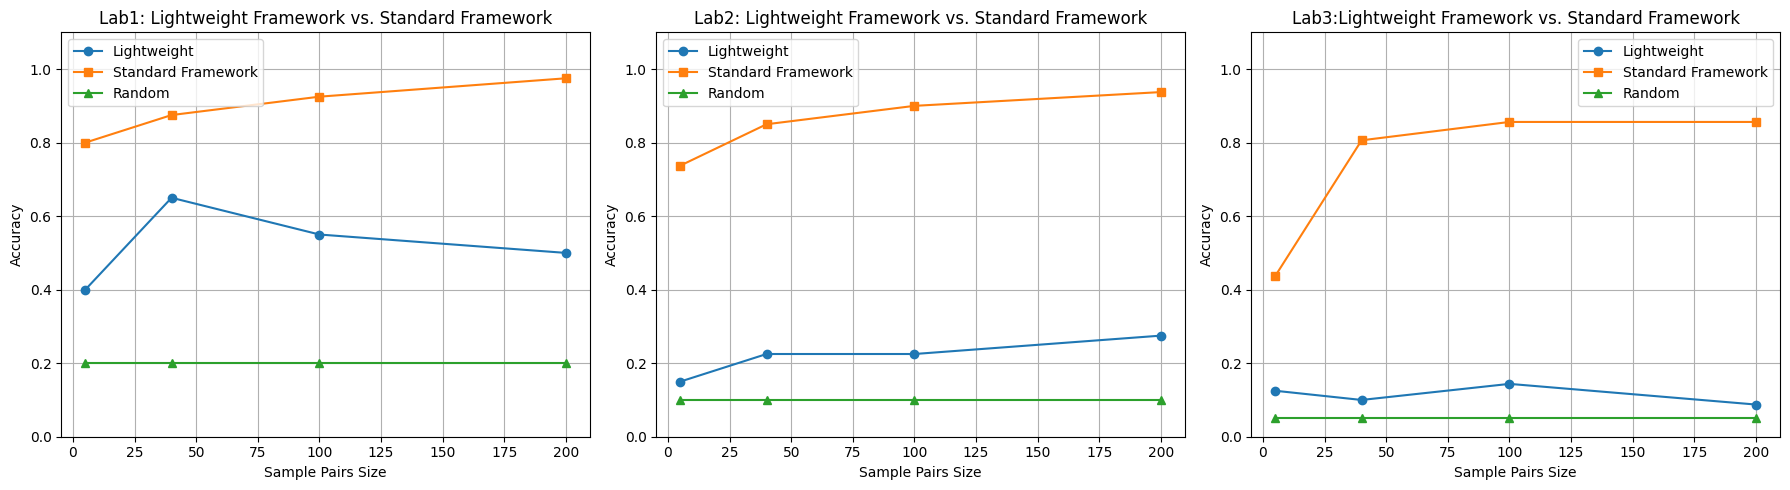

In [109]:
import matplotlib.pyplot as plt

lab3_rand = {s: [0.05] for s in scales}

# Average function
def avg(data):
    return [sum(data[s]) / len(data[s]) for s in scales]

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Lab1: Lightweight Framework vs. Standard Framework', 'Lab2: Lightweight Framework vs. Standard Framework', 'Lab3:Lightweight Framework vs. Standard Framework']
data_sets = [
    (avg(lab1_pca), avg(lab1_proj), avg(lab1_rand), ['Lightweight', 'Standard Framework', 'Random']),
    (avg(lab2_pca), avg(lab2_resnet), avg(lab2_rand), ['Lightweight', 'Standard Framework', 'Random']),
    (avg(lab3_pca), avg(lab3_resnet), avg(lab3_rand), ['Lightweight', 'Standard Framework', 'Random'])
]

for ax, (pca, other, rand, labels), title in zip(axs, data_sets, titles):
    ax.plot(scales, pca, marker='o', label=labels[0])
    ax.plot(scales, other, marker='s', label=labels[1])
    ax.plot(scales, rand, marker='^', label=labels[2])
    ax.set_title(title)
    ax.set_xlabel('Sample Pairs Size')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.1)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig("merged_comparison.png", format='png')
plt.show()

## 5.2 PCA + Encoder vs. Direct Encoder ##

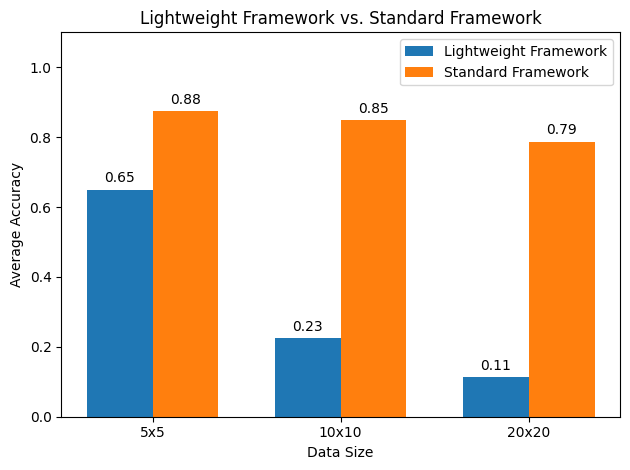

In [110]:
import matplotlib.pyplot as plt
import numpy as np

# Data
sizes = ['5x5', '10x10', '20x20']
pca_acc = [0.65, 0.225, 0.1125]
direct_acc = [0.875, 0.85, 0.7875]

x = np.arange(len(sizes))  # x-axis positions
width = 0.35  # width of the bars

fig, ax = plt.subplots()

# Plot bars
bars1 = ax.bar(x - width/2, pca_acc, width, label='Lightweight Framework')
bars2 = ax.bar(x + width/2, direct_acc, width, label='Standard Framework')

# Add labels and title
ax.set_xlabel('Data Size')
ax.set_ylabel('Average Accuracy')
ax.set_title('Lightweight Framework vs. Standard Framework')
ax.set_xticks(x)
ax.set_xticklabels(sizes)

# Place legend at upper right
ax.legend(loc='upper right')

# Display values on top of bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

ax.set_ylim(0, 1.1)
plt.tight_layout()

# Save as SVG file
plt.savefig('pca_vs_direct.png', format='png')

# Show plot
plt.show()

## 5.3 PCA-based lightweight framework performance(5x5)(40 sample number)

In [112]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def extract_embeddings(encoder, features):
    encoder.eval()
    with torch.no_grad():
        embeddings = encoder(torch.tensor(features, dtype=torch.float32))
    return embeddings.numpy()


def filter_classes_after_pca(features, labels, k=5, max_per_class=20):
    """Select top k classes after dimensionality reduction, with max_per_class samples per class"""
    selected_classes = np.unique(labels)[:k]
    selected_features = []
    selected_labels = []

    for cls in selected_classes:
        cls_indices = np.where(labels == cls)[0]
        if len(cls_indices) > max_per_class:
            cls_indices = np.random.choice(cls_indices, max_per_class, replace=False)
        selected_features.append(features[cls_indices])
        selected_labels.append(labels[cls_indices])

    return np.vstack(selected_features), np.hstack(selected_labels)


def visualize_combined_tsne(audio_embeds, image_embeds, audio_labels, image_labels, title, save_path):
    combined_embeds = np.vstack([audio_embeds, image_embeds])
    combined_labels = np.hstack([audio_labels, image_labels])
    audio_len = len(audio_labels)

    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(combined_embeds)

    unique_labels = np.unique(combined_labels)
    colors = plt.cm.get_cmap('tab10', len(unique_labels))

    plt.figure(figsize=(8, 6))
    for i, label in enumerate(unique_labels):
        idx_audio = np.where((combined_labels == label) & (np.arange(len(combined_labels)) < audio_len))[0]
        idx_image = np.where((combined_labels == label) & (np.arange(len(combined_labels)) >= audio_len))[0]

        plt.scatter(reduced[idx_audio, 0], reduced[idx_audio, 1],
                    label=f"Class {label} (Audio)", color=colors(i), s=20, marker='o')  # solid points
        plt.scatter(reduced[idx_image, 0], reduced[idx_image, 1],
                    label=f"Class {label} (Image)", facecolors='none', edgecolors=colors(i), s=40, marker='o')  # hollow points

    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


def main():
    np.random.seed(42)
    model_path = "./lab1/models_PCA/best_contrastive_model.pth"

    # 1. Standardize complete data
    scaler_audio = StandardScaler()
    scaler_image = StandardScaler()
    audio_scaled = scaler_audio.fit_transform(AUDIO_FEATURES)
    image_scaled = scaler_image.fit_transform(IMAGE_FEATURES)

    # 2. PCA dimensionality reduction to fixed 128 dimensions
    n_components = 128
    pca_audio = PCA(n_components=n_components)
    pca_image = PCA(n_components=n_components)
    audio_pca_all = pca_audio.fit_transform(audio_scaled)
    image_pca_all = pca_image.fit_transform(image_scaled)

    # 3. Filter top 5 classes from reduced data, max 20 samples per class
    audio_feats_filtered, audio_labels_filtered = filter_classes_after_pca(audio_pca_all, AUDIO_LABELS, k=5, max_per_class=20)
    image_feats_filtered, image_labels_filtered = filter_classes_after_pca(image_pca_all, IMAGE_LABELS, k=5, max_per_class=20)

    # 4. Load trained model
    old_audio_encoder = AudioEncoder(input_dim=n_components)
    old_image_encoder = ImageEncoder(input_dim=n_components)
    checkpoint = torch.load(model_path, map_location=torch.device("cpu"))
    old_audio_encoder.load_state_dict(checkpoint["audio_encoder"])
    old_image_encoder.load_state_dict(checkpoint["image_encoder"])

    # 5. Create untrained models
    new_audio_encoder = AudioEncoder(input_dim=n_components)
    new_image_encoder = ImageEncoder(input_dim=n_components)

    # 6. Extract embeddings
    old_audio_embeds = extract_embeddings(old_audio_encoder, audio_feats_filtered)
    old_image_embeds = extract_embeddings(old_image_encoder, image_feats_filtered)
    new_audio_embeds = extract_embeddings(new_audio_encoder, audio_feats_filtered)
    new_image_embeds = extract_embeddings(new_image_encoder, image_feats_filtered)

    # 7. Visualize trained model
    visualize_combined_tsne(
        audio_embeds=old_audio_embeds,
        image_embeds=old_image_embeds,
        audio_labels=audio_labels_filtered,
        image_labels=image_labels_filtered,
        title="Trained Model - Audio vs Image (5 Classes × 20)",
        save_path="combined_tsne_trained.png"
    )

    # 8. Visualize untrained model
    visualize_combined_tsne(
        audio_embeds=new_audio_embeds,
        image_embeds=new_image_embeds,
        audio_labels=audio_labels_filtered,
        image_labels=image_labels_filtered,
        title="Untrained Model - Audio vs Image (5 Classes × 20)",
        save_path="combined_tsne_untrained.png"
    )


if __name__ == "__main__":
    main()



NameError: name 'AUDIO_FEATURES' is not defined

## 5.4 Clip vs. ResNet50 as Image feature extraction method

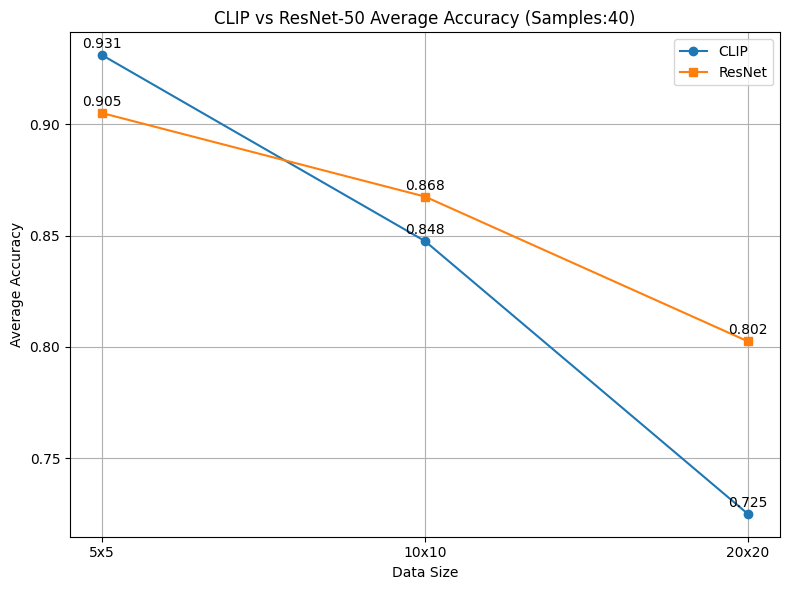

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Data
sizes = ['5x5', '10x10', '20x20']
clip_acc = [0.931, 0.8475, 0.725]
resnet_acc = [0.905, 0.8675, 0.8025]

x = np.arange(len(sizes))  # Numeric coordinates for line plot

fig, ax = plt.subplots(figsize=(8, 6))

# Plot line chart
ax.plot(x, clip_acc, marker='o', label='CLIP', linestyle='-')
ax.plot(x, resnet_acc, marker='s', label='ResNet', linestyle='-')

# Set axes and title
ax.set_xlabel('Data Size')
ax.set_ylabel('Average Accuracy')
ax.set_title('CLIP vs ResNet-50 Average Accuracy (Samples:40)')
ax.set_xticks(x)
ax.set_xticklabels(sizes)

# Display value labels
for i in range(len(x)):
    ax.annotate(f'{clip_acc[i]:.3f}', (x[i], clip_acc[i]), textcoords="offset points", xytext=(0, 5), ha='center')
    ax.annotate(f'{resnet_acc[i]:.3f}', (x[i], resnet_acc[i]), textcoords="offset points", xytext=(0, 5), ha='center')

ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()

# Save image
plt.savefig('clip_vs_resnet_line.png', format='png')

# Display plot
plt.show()